# Fraud Detection in Internship Applications

## Project Overview

Online internship portals receive thousands of applications from candidates with diverse educational backgrounds. As the number of applications increases, organizations face challenges in identifying suspicious or fraudulent submissions that may affect the fairness, transparency, and efficiency of the recruitment process.

This project analyzes an internship application dataset containing **100,000 application records** using **Data Analytics** and **Machine Learning** techniques to identify suspicious application patterns. The analysis focuses on common fraud indicators such as duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, incomplete applicant profiles, missing resumes, and inconsistent applicant data.

Exploratory Data Analysis (EDA) is performed to understand applicant behavior and identify fraud patterns within the dataset. Furthermore, **Isolation Forest** is applied for anomaly detection, while **K-Means Clustering** is used to group applications with similar characteristics. Finally, applications are categorized into different fraud risk levels to support effective recruitment decisions and facilitate further investigation of suspicious applications.

## Project Objectives

The main objectives of this project are:

- Identify anomalous internship applications to detect suspicious and potentially fraudulent submissions.
- Analyze common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, missing resumes, low profile completion, and inconsistent applicant data.
- Explore applicant behavior and fraud patterns using Exploratory Data Analysis (EDA).
- Apply the Isolation Forest algorithm to detect anomalous internship applications.
- Apply K-Means Clustering to group applications with similar characteristics.
- Categorize applications into different fraud risk levels to support effective decision-making and further investigation.

## Machine Learning Algorithms

The following unsupervised machine learning algorithms are used in this project to analyze internship applications, identify suspicious patterns, and support fraud detection.

### 1. Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm that identifies unusual internship applications by isolating observations that significantly differ from normal application behavior.

**Purpose:**

- Detect anomalous internship applications.
- Identify suspicious application behavior based on fraud-related features.
- Support fraud detection by highlighting potential anomalies for further investigation.


### 2. K-Means Clustering

K-Means Clustering is an unsupervised machine learning algorithm that groups internship applications into clusters based on similarities in applicant characteristics and application behavior.

**Purpose:**

- Discover hidden patterns within the internship application dataset.
- Group similar applications into meaningful clusters.
- Analyze behavioral differences among applicant groups.
- Support exploratory analysis of fraud-related application patterns.

## Dataset Information

The dataset used in this project contains internship application records submitted during **2025**. It includes applicant information, educational background, internship preferences, application behavior, device information, and fraud-related attributes.

The dataset is designed to identify suspicious internship applications by analyzing common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid application submissions, missing resumes, low profile completion, and inconsistent applicant data. It also supports anomaly detection using **Isolation Forest** and application segmentation using **K-Means Clustering**.

### Dataset Summary

| Attribute | Description |
|-----------|-------------|
| Project Title | Fraud Detection in Internship Applications |
| Domain | Data Analytics |
| Dataset Year | 2025 |
| Total Records | 100,000 |
| Total Features | 25 |
| Primary Fraud Label | Is_Fraud |
| Risk Indicator | Risk_Level |
| Fraud Score | Fraud_Score |
| Machine Learning Algorithms | Isolation Forest, K-Means Clustering |

### Dataset Overview

This project uses an internship application dataset containing **100,000 application records** submitted during **2025**. The dataset includes applicant information, educational background, internship preferences, application behavior, device information, submission details, and fraud-related attributes used to identify suspicious and potentially fraudulent applications.

#### Dataset Features

| Column | Description |
|---------|-------------|
| Application_ID | Unique identifier assigned to each internship application. |
| Applicant_Name | Full name of the applicant. |
| Email | Applicant's email address used during registration. |
| Age | Age of the applicant in years. |
| Gender | Gender of the applicant. |
| City | City of residence of the applicant. |
| Education_Level | Highest educational qualification of the applicant. |
| Institute | Educational institute attended by the applicant. |
| Department | Department selected for the internship application. |
| Internship_Track | Internship track selected by the applicant. |
| CGPA | Applicant's cumulative grade point average (CGPA). |
| Experience_Level | Previous internship or work experience level. |
| Application_Date | Date on which the application was submitted. |
| Application_Time | Time at which the application was submitted. |
| Submission_Gap_Seconds | Time interval between consecutive application submissions. |
| IP_Address | IP address used during the application submission. |
| Device_ID | Unique device identifier used during the application submission. |
| Browser | Web browser used during the application submission. |
| Operating_System | Operating system of the applicant's device. |
| Resume_Uploaded | Indicates whether the applicant uploaded a resume. |
| Profile_Completion | Percentage of profile completion at the time of submission. |
| Fraud_Score | Fraud score assigned based on detected fraud indicators. |
| Fraud_Reason | One or more detected fraud indicators associated with the application. |
| Is_Fraud | Binary fraud label where **1** represents a fraudulent application and **0** represents a genuine application. |
| Risk_Level | Fraud risk category assigned to the application (**Genuine**, **Low Risk**, **Medium Risk**, **High Risk**, or **Critical Risk**). |

## Import Required Libraries

The following Python libraries are imported to support the complete machine learning workflow of this project. These libraries are used for data manipulation, data visualization, feature scaling, anomaly detection, clustering, dimensionality reduction, and model evaluation throughout the internship fraud detection analysis.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# ------------------------------------------
# Data Manipulation
# ------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------
# Data Visualization
# ------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------
# Text Formatting
# ------------------------------------------

import textwrap


# ------------------------------------------
# Data Preprocessing
# ------------------------------------------

from sklearn.preprocessing import StandardScaler


# ------------------------------------------
# Anomaly Detection
# ------------------------------------------

from sklearn.ensemble import IsolationForest


# ------------------------------------------
# Clustering
# ------------------------------------------

from sklearn.cluster import KMeans


# ------------------------------------------
# Dimensionality Reduction
# ------------------------------------------

from sklearn.decomposition import PCA


# ------------------------------------------
# Model Evaluation
# ------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

## Load Dataset

The internship application dataset is loaded into a Pandas DataFrame for analysis.

To preserve the original dataset, a separate copy (`df_clean`) is created. This copy is used for data preprocessing, data cleaning, and Exploratory Data Analysis (EDA). A separate dataset will later be prepared during the Machine Learning phase for feature engineering, preprocessing, and model development.

In [2]:
# ==========================================
# Load Dataset
# ==========================================

# Load Dataset
df = pd.read_csv(
    "../dataset/raw/internship_applications_2025.csv"
)

# Create a Copy of the Dataset
df_clean = df.copy()

## Initial Dataset Exploration

Before performing data preprocessing and exploratory data analysis (EDA), the dataset is initially explored to understand its overall structure and quality. The first few records are displayed to verify that the dataset has been loaded correctly and that all features are available for further analysis.

In [3]:
# ==========================================
# Display First Five Records
# ==========================================

df.head().T

,0,1,2,3,4
Application_ID,APP000001,APP000002,APP000003,APP000004,APP000005
Applicant_Name,Waqar Ismail,Sameer Siddiqui,Muzammil Dar,Mohsin Jatoi,Sahar Zubair
Email,waqar.ismail.000001@outlook.com,sameer.siddiqui.000002@gmail.com,muzammil.dar.000003@gmail.com,mohsin.jatoi.000004@yahoo.com,sahar.zubair.000005@gmail.com
Age,18,27,26,23,20
Gender,Male,Male,Male,Male,Female
City,Bahawalpur,Multan,Quetta,Peshawar,Karachi
Education_Level,BS Software Engineering,BS Cyber Security,FSC (Pre-Medical),BS Computer Science,BS Information Technology
Institute,National University of Sciences and Technology,Virtual University of Pakistan,Superior College,Iqra University,University of Management and Technology
Department,Frontend Development,Backend Development,Graphic Design,Graphic Design,App Development
Internship_Track,React,PHP,Illustrator,Illustrator,Flutter


In [4]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 100,000
Number of Columns : 25


In [5]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Application_ID          100000 non-null  str    
 1   Applicant_Name          100000 non-null  str    
 2   Email                   100000 non-null  str    
 3   Age                     100000 non-null  int64  
 4   Gender                  100000 non-null  str    
 5   City                    100000 non-null  str    
 6   Education_Level         100000 non-null  str    
 7   Institute               100000 non-null  str    
 8   Department              100000 non-null  str    
 9   Internship_Track        100000 non-null  str    
 10  CGPA                    100000 non-null  float64
 11  Experience_Level        100000 non-null  str    
 12  Application_Date        100000 non-null  str    
 13  Application_Time        100000 non-null  str    
 14  Submission_Gap_Seconds  100000 n

**Observation:**

- The dataset contains **100,000 internship application records** with **25 features**.
- Most columns contain **100,000 non-null values**, indicating that the dataset is complete and well-structured.
- The **Fraud_Reason** column contains **19,450 non-null values**, while the remaining records are missing because fraud reasons are assigned only to suspicious applications.
- The dataset consists of **19 string**, **5 integer**, and **1 float** data types, making it suitable for exploratory data analysis (EDA), anomaly detection, and machine learning.
- The dataset occupies approximately **39.3 MB** of memory, allowing efficient analysis on standard computing systems.

In [6]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Fraud_Reason    80550
dtype: int64

In [7]:
# ==========================================
# Duplicate Records
# ==========================================

print(f"Duplicate Records : {df.duplicated().sum():,}")

Duplicate Records : 0


**Observation:**

- The dataset contains only one feature with missing values, **Fraud_Reason**.
- Missing values in **Fraud_Reason** are expected because fraud reasons are assigned only to suspicious applications, while genuine applications do not have any associated fraud reason.
- No completely duplicated records were found in the dataset.
- Overall, the dataset is clean, well-structured, and ready for preprocessing and fraud pattern analysis.

## Handling Missing Values

Before performing exploratory data analysis and machine learning, missing values are handled appropriately. Since the **Fraud_Reason** column is applicable only to suspicious applications, its missing values are expected rather than data quality issues. Therefore, all missing values are replaced with **"None"** to ensure consistency during analysis and visualization.

In [8]:
# ==========================================
# Missing Values Before Preprocessing
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Fraud_Reason    80550
dtype: int64

In [9]:
# ==========================================
# Fill Missing Fraud Reasons
# ==========================================

df_clean["Fraud_Reason"] = df_clean["Fraud_Reason"].fillna("None")

In [10]:
# ==========================================
# Verify Missing Values
# ==========================================

print(
    f"Missing Values in Fraud_Reason : "
    f"{df_clean['Fraud_Reason'].isnull().sum()}"
)

Missing Values in Fraud_Reason : 0


**Observation:**

- All missing values in the **Fraud_Reason** column have been successfully replaced with **"None"**.
- The dataset no longer contains missing values.
- The cleaned dataset (`df_clean`) is consistent and ready for exploratory data analysis, anomaly detection, and machine learning.

In [11]:
# ==========================================
# Fraud Reason Value Counts
# ==========================================

df_clean["Fraud_Reason"].value_counts(dropna=False)

Fraud_Reason
None                                                                                                         80550
Duplicate IP                                                                                                  4142
Rapid Submission                                                                                              3055
Duplicate Device                                                                                              2643
Resume Missing                                                                                                2065
Low Profile Completion                                                                                        1569
Duplicate Email                                                                                                866
Duplicate IP, Rapid Submission                                                                                 744
Inconsistent Data                                                  

## Fraud Pattern Analysis

This section analyzes fraud-related patterns in the internship application dataset. The analysis focuses on fraud risk levels and common fraud indicators, including duplicate email addresses, duplicate IP addresses, duplicate device IDs, rapid submissions, missing resumes, and low profile completion.

The objective is to understand suspicious application behavior, identify common fraud patterns, and provide meaningful insights before applying machine learning techniques for anomaly detection and clustering.

### Risk Level Distribution

This analysis presents the distribution of internship applications across different fraud risk levels. It provides an overview of how applications are categorized based on their fraud scores and helps understand the overall risk profile of the dataset.

In [12]:
# ==========================================
# Risk Level Distribution
# ==========================================

risk_level_counts = (
    df_clean["Risk_Level"]
    .value_counts()
)

risk_level_counts

Risk_Level
Genuine     80550
Low         13856
Medium       4875
High          575
Critical      144
Name: count, dtype: int64

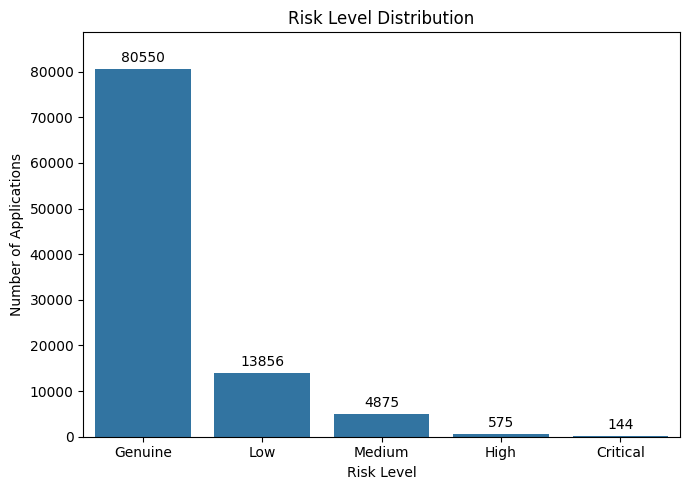

In [13]:
# ==========================================
# Risk Level Distribution
# ==========================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="Risk_Level",
    order=risk_level_counts.index
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, risk_level_counts.max() * 1.10)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/01_risk_level_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The majority of applications are classified as **Genuine (80,550)**, indicating that most applicants exhibit normal application behavior.
- Among suspicious applications, **Low Risk (13,856)** represents the largest category, followed by **Medium Risk (4,875)**, while **High Risk (575)** and **Critical Risk (144)** applications are comparatively rare.
- The distribution indicates that most suspicious applications contain relatively lower fraud scores, whereas only a small proportion are categorized as High or Critical Risk.
- Overall, the risk level distribution reflects a realistic fraud detection scenario where genuine applications significantly outnumber suspicious applications.

### Individual Fraud Reason Distribution

This analysis presents the frequency of each individual fraud indicator detected in internship applications. It helps identify the most common suspicious activities and provides insights into the distribution of fraud indicators across the dataset.

In [14]:
# ==========================================
# Individual Fraud Reason Distribution
# ==========================================

fraud_reason_counts = (
    df_clean.loc[
        df_clean["Fraud_Reason"] != "None",
        "Fraud_Reason"
    ]
    .str.split(", ")
    .explode()
    .value_counts()
)

fraud_reason_counts

Fraud_Reason
Duplicate IP              5914
Rapid Submission          5847
Duplicate Device          4974
Resume Missing            3074
Duplicate Email           2867
Low Profile Completion    2477
Inconsistent Data          636
Name: count, dtype: int64

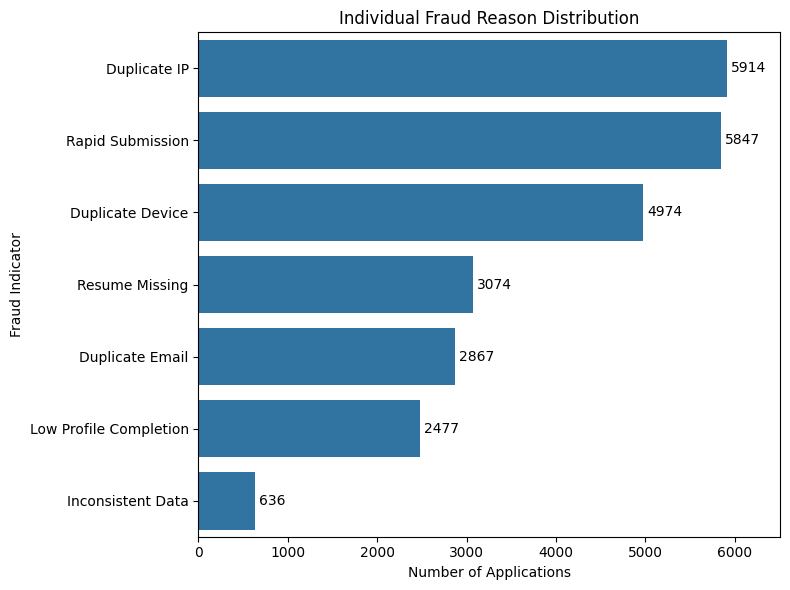

In [15]:
# ==========================================
# Individual Fraud Reason Distribution
# ==========================================

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=fraud_reason_counts.values,
    y=fraud_reason_counts.index
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, fraud_reason_counts.max() * 1.10)

plt.title("Individual Fraud Reason Distribution")
plt.xlabel("Number of Applications")
plt.ylabel("Fraud Indicator")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/02_individual_fraud_reason_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Duplicate IP (5,914)** is the most frequently detected fraud indicator, followed by **Rapid Submission (5,847)** and **Duplicate Device (4,974)**, indicating that duplicate network activity and abnormal submission behavior are the most common suspicious patterns.
- **Resume Missing (3,074)**, **Duplicate Email (2,867)**, and **Low Profile Completion (2,477)** are also frequently observed, while **Inconsistent Data (636)** is the least common fraud indicator.
- A single internship application may contain multiple fraud indicators; therefore, the combined frequency of individual fraud indicators is greater than the total number of fraudulent applications.
- Overall, duplicate-related and behavioral fraud indicators are more prevalent than profile-related issues, highlighting the primary patterns of suspicious activity within the dataset.

### Duplicate Email Analysis

This analysis examines internship applications associated with duplicate email addresses. Duplicate email records may indicate repeated applications submitted by the same applicant or suspicious attempts to increase the chances of selection.

In [16]:
# ==========================================
# Duplicate Email Applications
# ==========================================

duplicate_email = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate Email")
]

duplicate_email_count = duplicate_email.shape[0]

print(f"Duplicate Email Applications : {duplicate_email_count:,}")

Duplicate Email Applications : 2,867


In [17]:
# ==========================================
# Verify Duplicate Email Records
# ==========================================

duplicate_email_records = (
    df_clean["Email"]
    .duplicated()
    .sum()
)

print(f"Duplicate Email Records : {duplicate_email_records:,}")

Duplicate Email Records : 2,867


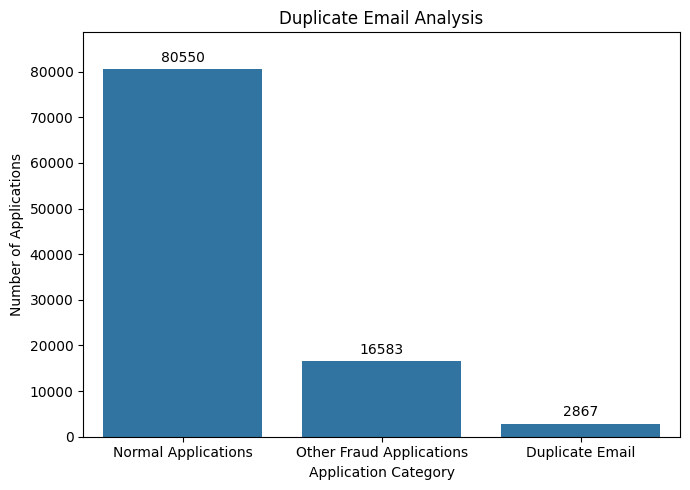

In [18]:
# ==========================================
# Duplicate Email Analysis
# ==========================================

email_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate Email")
        ],
        [
            "Normal Applications",
            "Duplicate Email"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories
email_status = email_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate Email"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=email_status.index,
    y=email_status.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, email_status.max() * 1.10)

plt.title("Duplicate Email Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/03_duplicate_email_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **2,867** internship applications are associated with the **Duplicate Email** fraud indicator.
- Verification using the original **Email** column confirms that **2,867 duplicate email records** are present, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **16,583 Other Fraud Applications** contain fraud indicators other than **Duplicate Email**.
- Duplicate email addresses may indicate repeated application submissions using the same email account, making them an important indicator of potentially suspicious application behavior.

### Duplicate IP Analysis

This analysis examines internship applications submitted from duplicate IP addresses. Multiple applications originating from the same IP address may indicate repeated submissions from a shared network or suspicious application activity.

In [19]:
# ==========================================
# Duplicate IP Applications
# ==========================================

duplicate_ip = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate IP")
]

duplicate_ip_count = duplicate_ip.shape[0]

print(f"Duplicate IP Applications : {duplicate_ip_count:,}")

Duplicate IP Applications : 5,914


In [20]:
# ==========================================
# Verify Duplicate IP Records
# ==========================================

duplicate_ip_records = (
    df_clean["IP_Address"]
    .duplicated()
    .sum()
)

print(f"Duplicate IP Records : {duplicate_ip_records:,}")

Duplicate IP Records : 5,914


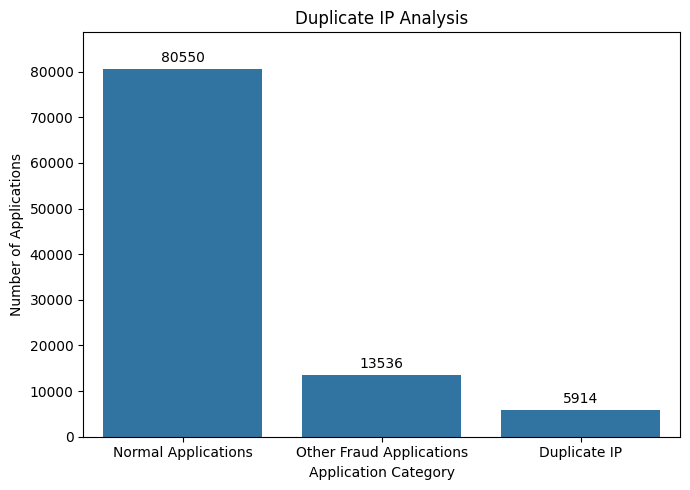

In [21]:
# ==========================================
# Duplicate IP Analysis
# ==========================================

ip_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate IP")
        ],
        [
            "Normal Applications",
            "Duplicate IP"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

ip_status = ip_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate IP"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=ip_status.index,
    y=ip_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, ip_status.max() * 1.10)

plt.title("Duplicate IP Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/04_duplicate_ip_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **5,914** internship applications are associated with the **Duplicate IP** fraud indicator.
- Verification using the original **IP_Address** column confirms that **5,914 duplicate IP records** are present, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **13,536 Other Fraud Applications** contain fraud indicators other than **Duplicate IP**.
- Duplicate IP addresses may indicate repeated application submissions from the same network or device, making them an important indicator of potentially suspicious application behavior.

### Duplicate Device Analysis

This analysis examines internship applications submitted using duplicate device IDs. Multiple applications originating from the same device may indicate repeated submissions from a single device or suspicious application activity.

In [22]:
# ==========================================
# Duplicate Device Applications
# ==========================================

duplicate_device = df_clean[
    df_clean["Fraud_Reason"].str.contains("Duplicate Device")
]

duplicate_device_count = duplicate_device.shape[0]

print(f"Duplicate Device Applications : {duplicate_device_count:,}")

Duplicate Device Applications : 4,974


In [23]:
# ==========================================
# Verify Duplicate Device Records
# ==========================================

duplicate_device_records = (
    df_clean["Device_ID"]
    .duplicated()
    .sum()
)

print(f"Duplicate Device Records : {duplicate_device_records:,}")

Duplicate Device Records : 4,974


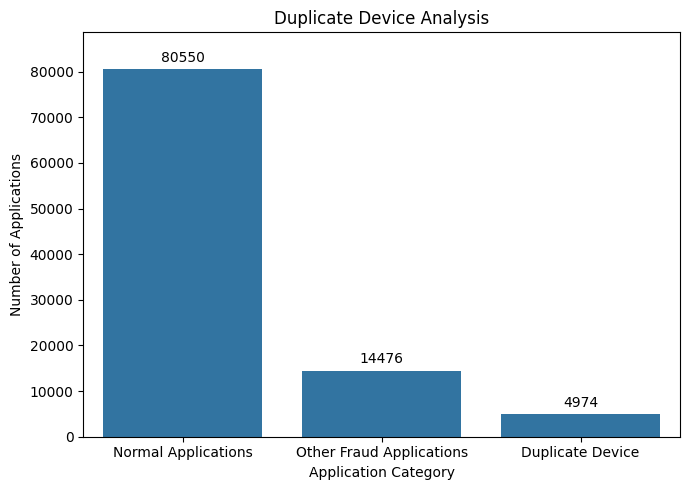

In [24]:
# ==========================================
# Duplicate Device Analysis
# ==========================================

device_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Duplicate Device")
        ],
        [
            "Normal Applications",
            "Duplicate Device"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

device_status = device_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Duplicate Device"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=device_status.index,
    y=device_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, device_status.max() * 1.10)

plt.title("Duplicate Device Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/05_duplicate_device_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **4,974** internship applications are associated with the **Duplicate Device** fraud indicator.
- Verification using the original **Device_ID** column confirms that **4,974 duplicate device records** are present, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **14,476 Other Fraud Applications** contain fraud indicators other than **Duplicate Device**.
- Duplicate device IDs may indicate that multiple internship applications were submitted from the same device, making them an important indicator of potentially suspicious application behavior.

### Rapid Submission Analysis

This analysis examines internship applications submitted within a very short time interval. Rapid submissions may indicate automated scripts, repeated application attempts, or suspicious application behavior that requires further investigation.

In [25]:
# ==========================================
# Rapid Submission Applications
# ==========================================

rapid_submission = df_clean[
    df_clean["Fraud_Reason"].str.contains("Rapid Submission")
]

rapid_submission_count = rapid_submission.shape[0]

print(f"Rapid Submission Applications : {rapid_submission_count:,}")

Rapid Submission Applications : 5,847


In [26]:
# ==========================================
# Verify Rapid Submission Records
# ==========================================

rapid_submission_records = (
    df_clean["Submission_Gap_Seconds"]
    .lt(30)
    .sum()
)

print(f"Rapid Submission Records : {rapid_submission_records:,}")

Rapid Submission Records : 5,847


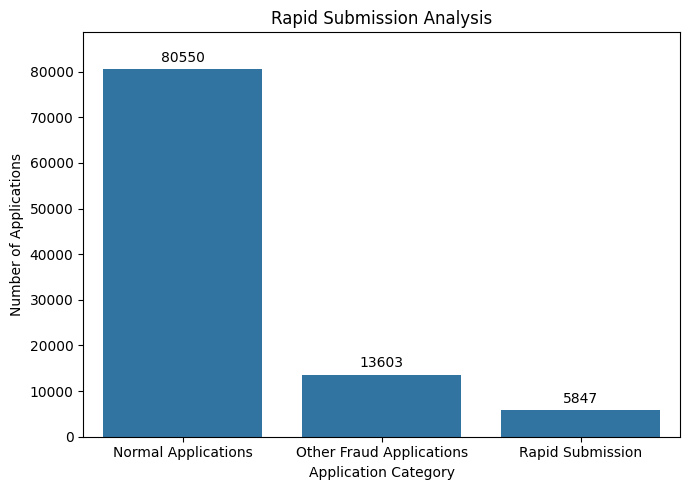

In [27]:
# ==========================================
# Rapid Submission Analysis
# ==========================================

rapid_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Rapid Submission")
        ],
        [
            "Normal Applications",
            "Rapid Submission"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

rapid_status = rapid_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Rapid Submission"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=rapid_status.index,
    y=rapid_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, rapid_status.max() * 1.10)

plt.title("Rapid Submission Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/06_rapid_submission_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **5,847** internship applications are associated with the **Rapid Submission** fraud indicator.
- Verification using the original **Submission_Gap_Seconds** column confirms that **5,847 rapid submission records** are present, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **13,603 Other Fraud Applications** contain fraud indicators other than **Rapid Submission**.
- Very short **Submission_Gap_Seconds** values may indicate automated or unusually fast application submissions, making them an important indicator of potentially suspicious application behavior.

### Resume Missing Analysis

This analysis examines internship applications where applicants did not upload a resume. Missing resumes may indicate incomplete applications or suspicious submission behavior, as resumes are typically required during the application process.

In [28]:
# ==========================================
# Resume Missing Applications
# ==========================================

resume_missing = df_clean[
    df_clean["Fraud_Reason"].str.contains("Resume Missing")
]

resume_missing_count = resume_missing.shape[0]

print(f"Resume Missing Applications : {resume_missing_count:,}")

Resume Missing Applications : 3,074


In [29]:
# ==========================================
# Verify Resume Missing Records
# ==========================================

resume_missing_records = (
    df_clean["Resume_Uploaded"]
    .eq("No")
    .sum()
)

print(f"Resume Missing Records : {resume_missing_records:,}")

Resume Missing Records : 3,074


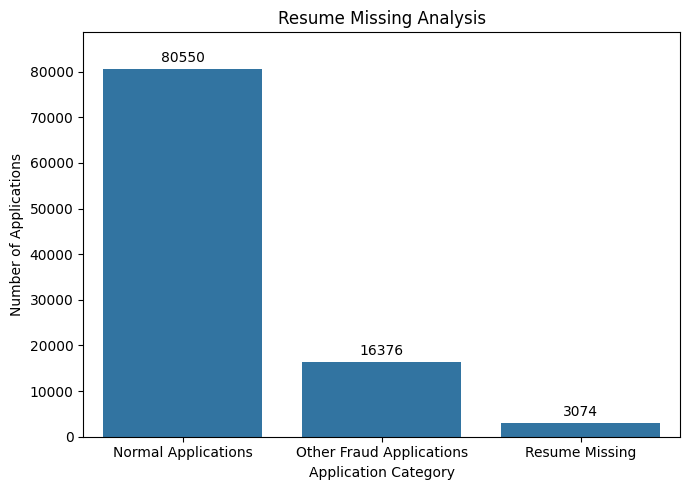

In [30]:
# ==========================================
# Resume Missing Analysis
# ==========================================

resume_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Resume Missing")
        ],
        [
            "Normal Applications",
            "Resume Missing"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

resume_status = resume_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Resume Missing"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=resume_status.index,
    y=resume_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, resume_status.max() * 1.10)

plt.title("Resume Missing Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/07_resume_missing_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **3,074** internship applications are associated with the **Resume Missing** fraud indicator.
- Verification using the original **Resume_Uploaded** column confirms that **3,074 applications** do not have a resume uploaded, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **16,376 Other Fraud Applications** contain fraud indicators other than **Resume Missing**.
- Applications without uploaded resumes may indicate incomplete submissions or intentionally omitted applicant information, making them an important indicator of potentially suspicious application behavior.

### Low Profile Completion Analysis

This analysis examines internship applications with low profile completion percentages. Incomplete applicant profiles may indicate insufficient information or suspicious application behavior, making them an important factor in fraud analysis.

In [31]:
# ==========================================
# Low Profile Completion Applications
# ==========================================

low_profile = df_clean[
    df_clean["Fraud_Reason"].str.contains("Low Profile Completion")
]

low_profile_count = low_profile.shape[0]

print(f"Low Profile Completion Applications : {low_profile_count:,}")

Low Profile Completion Applications : 2,477


In [32]:
# ==========================================
# Verify Low Profile Completion Records
# ==========================================

low_profile_records = (
    df_clean["Profile_Completion"]
    .le(40)
    .sum()
)

print(f"Low Profile Completion Records : {low_profile_records:,}")

Low Profile Completion Records : 2,477


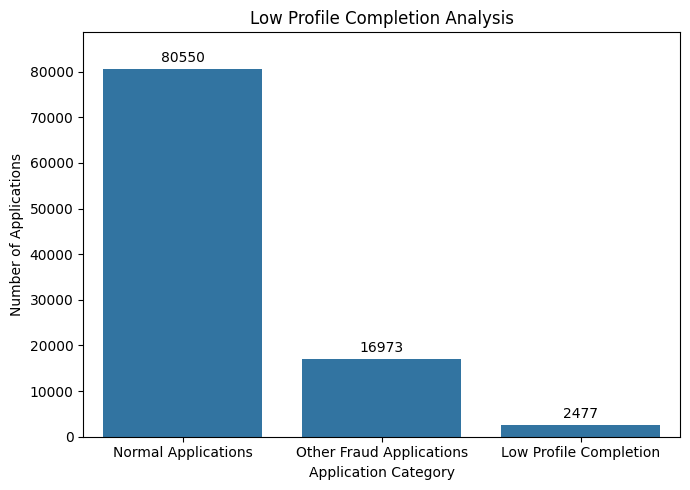

In [33]:
# ==========================================
# Low Profile Completion Analysis
# ==========================================

profile_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Low Profile Completion")
        ],
        [
            "Normal Applications",
            "Low Profile Completion"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

profile_status = profile_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Low Profile Completion"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=profile_status.index,
    y=profile_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, profile_status.max() * 1.10)

plt.title("Low Profile Completion Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/08_low_profile_completion_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **2,477** internship applications are associated with the **Low Profile Completion** fraud indicator.
- Verification using the original **Profile_Completion** column confirms that **2,477 low profile completion records** are present, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **16,973 Other Fraud Applications** contain fraud indicators other than **Low Profile Completion**.
- Applications with low **Profile_Completion** percentages may indicate incomplete applicant information, making them an important indicator of potentially suspicious application behavior.

### Inconsistent Data Analysis

This analysis examines internship applications containing inconsistent academic information. In this project, inconsistent data refers to applications with abnormal CGPA values that may indicate incorrect, unrealistic, or suspicious applicant information.

In [34]:
# ==========================================
# Inconsistent Data Applications
# ==========================================

inconsistent_data = df_clean[
    df_clean["Fraud_Reason"].str.contains("Inconsistent Data")
]

inconsistent_data_count = inconsistent_data.shape[0]

print(f"Inconsistent Data Applications : {inconsistent_data_count:,}")

Inconsistent Data Applications : 636


In [35]:
# ==========================================
# Verify Inconsistent Data Records
# ==========================================

inconsistent_data_records = (
    df_clean["CGPA"]
    .lt(2.00)
    .sum()
)

print(f"Inconsistent Data Records : {inconsistent_data_records:,}")

Inconsistent Data Records : 636


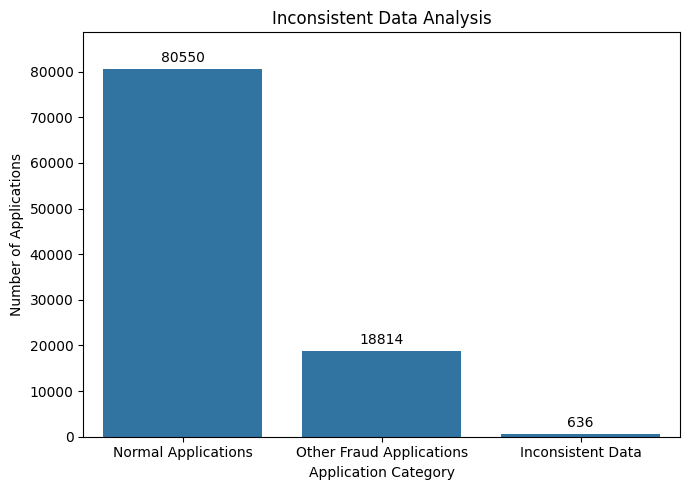

In [36]:
# ==========================================
# Inconsistent Data Analysis
# ==========================================

inconsistent_status = pd.Series(
    np.select(
        [
            df_clean["Fraud_Reason"] == "None",
            df_clean["Fraud_Reason"].str.contains("Inconsistent Data")
        ],
        [
            "Normal Applications",
            "Inconsistent Data"
        ],
        default="Other Fraud Applications"
    )
).value_counts()

# Reorder Categories

inconsistent_status = inconsistent_status.reindex([
    "Normal Applications",
    "Other Fraud Applications",
    "Inconsistent Data"
])

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=inconsistent_status.index,
    y=inconsistent_status.values
)

# Add Data Labels

for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit

ax.set_ylim(0, inconsistent_status.max() * 1.10)

plt.title("Inconsistent Data Analysis")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/09_inconsistent_data_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- A total of **636** internship applications are associated with the **Inconsistent Data** fraud indicator.
- Verification using the original **CGPA** column confirms that **636 applications** contain inconsistent academic information based on the defined CGPA threshold, indicating consistency between the dataset and the assigned fraud labels.
- The dataset contains **80,550 Normal Applications**, while **18,814 Other Fraud Applications** contain fraud indicators other than **Inconsistent Data**.
- In this project, **Inconsistent Data** refers to applications with **CGPA values below 2.00**, which may represent unrealistic or suspicious academic information requiring further investigation.

### Multiple Fraud Indicator Analysis

This analysis examines the number of fraud indicators associated with each internship application. Applications containing multiple fraud indicators are generally considered more suspicious and may require a higher level of investigation than applications with only a single fraud indicator.

In [37]:
# ==========================================
# Multiple Fraud Indicator Distribution
# ==========================================

fraud_indicator_count = (
    df_clean["Fraud_Reason"]
    .apply(
        lambda x: 0 if x == "None"
        else len(x.split(", "))
    )
)

fraud_indicator_distribution = (
    fraud_indicator_count
    .replace({
        0: "Normal Applications",
        1: "Single Fraud Indicator",
        2: "Two Fraud Indicators",
        3: "Three Fraud Indicators",
        4: "Four Fraud Indicators",
        5: "Five Fraud Indicators",
        6: "Six Fraud Indicators"
    })
    .value_counts()
)

fraud_indicator_distribution

Fraud_Reason
Normal Applications       80550
Single Fraud Indicator    14976
Two Fraud Indicators       3306
Three Fraud Indicators      778
Five Fraud Indicators       223
Four Fraud Indicators       125
Six Fraud Indicators         42
Name: count, dtype: int64

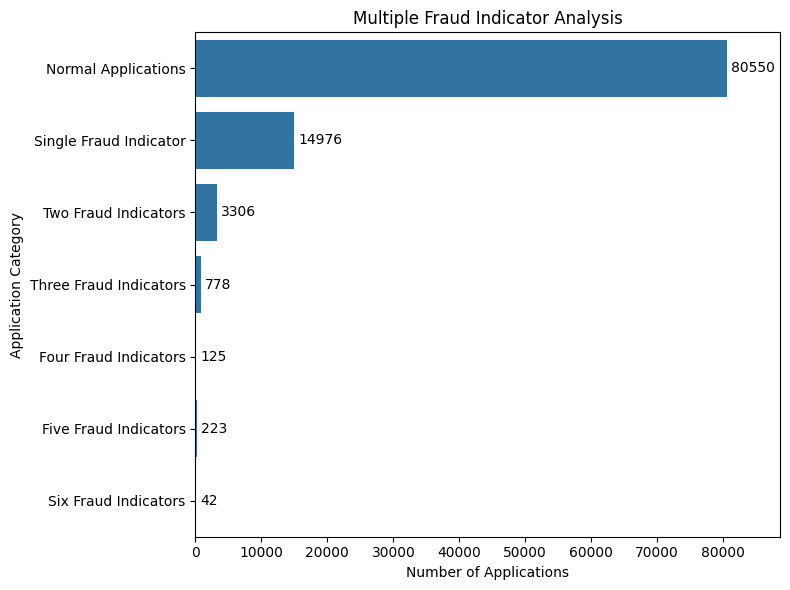

In [38]:
# ==========================================
# Multiple Fraud Indicator Analysis
# ==========================================

fraud_indicator_distribution = fraud_indicator_distribution.reindex([
    "Normal Applications",
    "Single Fraud Indicator",
    "Two Fraud Indicators",
    "Three Fraud Indicators",
    "Four Fraud Indicators",
    "Five Fraud Indicators",
    "Six Fraud Indicators"
])

plt.figure(figsize=(8,6))

ax = sns.barplot(
    y=fraud_indicator_distribution.index,
    x=fraud_indicator_distribution.values
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, fraud_indicator_distribution.max() * 1.10)

plt.title("Multiple Fraud Indicator Analysis")
plt.xlabel("Number of Applications")
plt.ylabel("Application Category")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/10_multiple_fraud_indicator_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The majority of internship applications (**80,550**) contain **no fraud indicators** and are classified as **Normal Applications**.
- Among suspicious applications, **Single Fraud Indicator (14,976)** is the most common category, indicating that most fraudulent applications exhibit only one suspicious characteristic.
- The number of applications decreases as the number of fraud indicators increases, with **3,306** applications containing **two**, **778** containing **three**, **125** containing **four**, **223** containing **five**, and only **42** containing **six fraud indicators**.
- Applications containing multiple fraud indicators are relatively rare but represent more complex and potentially higher-risk cases that may require additional investigation.

## Feature-wise Fraud Analysis

This section explores the relationship between applicant characteristics and fraud patterns. It examines how fraudulent internship applications are distributed across different applicant features to identify patterns associated with suspicious application behavior.

### Department-wise Fraud Analysis

This analysis compares the distribution of genuine and fraudulent internship applications across different departments. It also reports the fraud rate for each department, helping identify departments with a relatively higher proportion of suspicious applications.

In [39]:
# ==========================================
# Department-wise Fraud Summary
# ==========================================

department_summary = (
    df_clean
    .groupby("Department")["Is_Fraud"]
    .agg(
        Total_Applications="count",
        Fraud_Applications="sum"
    )
)

department_summary["Genuine_Applications"] = (
    department_summary["Total_Applications"]
    - department_summary["Fraud_Applications"]
)

department_summary["Fraud_Rate (%)"] = (
    department_summary["Fraud_Applications"]
    / department_summary["Total_Applications"]
    * 100
).round(2)

department_summary = (
    department_summary[
        [
            "Total_Applications",
            "Genuine_Applications",
            "Fraud_Applications",
            "Fraud_Rate (%)"
        ]
    ]
    .sort_values("Fraud_Rate (%)", ascending=False)
)

department_summary

,Total_Applications,Genuine_Applications,Fraud_Applications,Fraud_Rate (%)
Department,,,,
Other Internships,11235,8958,2277,20.27
Graphic Design,12808,10284,2524,19.71
App Development,15742,12679,3063,19.46
Chatbot Development,8183,6591,1592,19.45
Backend Development,24567,19827,4740,19.29
Frontend Development,27465,22211,5254,19.13


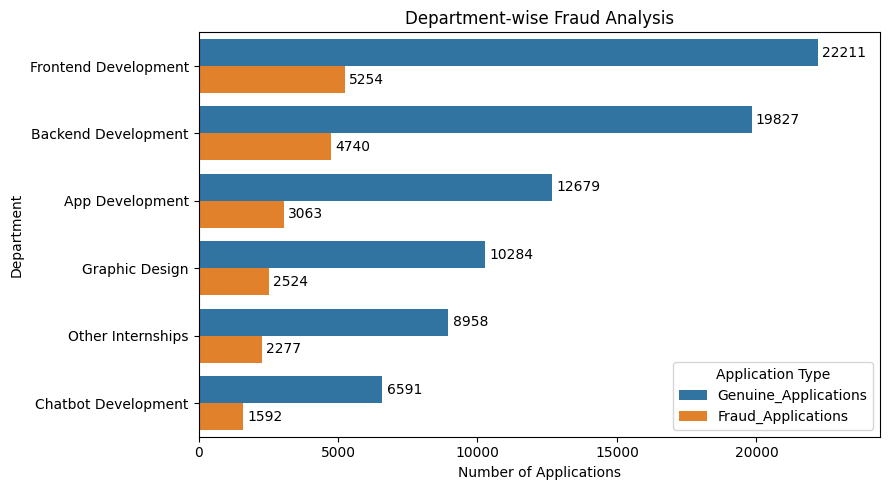

In [40]:
# ==========================================
# Department-wise Fraud Analysis
# ==========================================

department_plot = (
    department_summary
    .sort_values("Fraud_Applications", ascending=False)
    [["Genuine_Applications", "Fraud_Applications"]]
    .reset_index()
    .melt(
        id_vars="Department",
        var_name="Application_Type",
        value_name="Applications"
    )
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=department_plot,
    y="Department",
    x="Applications",
    hue="Application_Type"
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, department_plot["Applications"].max() * 1.10)

plt.title("Department-wise Fraud Analysis")
plt.xlabel("Number of Applications")
plt.ylabel("Department")

plt.legend(title="Application Type")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/11_department_wise_fraud_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Frontend Development** receives the highest number of applications (**27,465**), including **22,211 genuine** and **5,254 fraudulent** applications, while **Chatbot Development** receives the fewest applications (**8,183**) with **6,591 genuine** and **1,592 fraudulent** applications.
- The highest fraud rate is observed in **Other Internships (20.27%)**, followed by **Graphic Design (19.71%)**, whereas **Frontend Development (19.13%)** has the lowest fraud rate among all departments despite recording the highest number of fraudulent applications.
- Genuine applications outnumber fraudulent applications across every department, indicating that legitimate submissions remain the majority regardless of the internship domain.
- Overall, both the volume of applications and the fraud rate vary across departments, suggesting that certain internship domains are relatively more susceptible to suspicious application activity.

### Internship Track-wise Fraud Analysis

This analysis compares the distribution of genuine and fraudulent internship applications across different internship tracks. It also reports the fraud rate for each internship track, helping identify career paths with a relatively higher proportion of suspicious applications.

In [41]:
# ==========================================
# Internship Track-wise Fraud Summary
# ==========================================

track_summary = (
    df_clean
    .groupby("Internship_Track")["Is_Fraud"]
    .agg(
        Total_Applications="count",
        Fraud_Applications="sum"
    )
)

track_summary["Genuine_Applications"] = (
    track_summary["Total_Applications"]
    - track_summary["Fraud_Applications"]
)

track_summary["Fraud_Rate (%)"] = (
    track_summary["Fraud_Applications"]
    / track_summary["Total_Applications"]
    * 100
).round(2)

track_summary = (
    track_summary[
        [
            "Total_Applications",
            "Genuine_Applications",
            "Fraud_Applications",
            "Fraud_Rate (%)"
        ]
    ]
    .sort_values("Fraud_Rate (%)", ascending=False)
)

track_summary

,Total_Applications,Genuine_Applications,Fraud_Applications,Fraud_Rate (%)
Internship_Track,,,,
Data Analytics,1570,1238,332,21.15
Video Editing,1633,1294,339,20.76
Flutter,3929,3115,814,20.72
Cloud Computing,1622,1286,336,20.72
Illustrator,3127,2484,643,20.56
Cyber Security,1625,1291,334,20.55
WordPress,4007,3185,822,20.51
Data Science,1544,1232,312,20.21
RASA,1725,1381,344,19.94


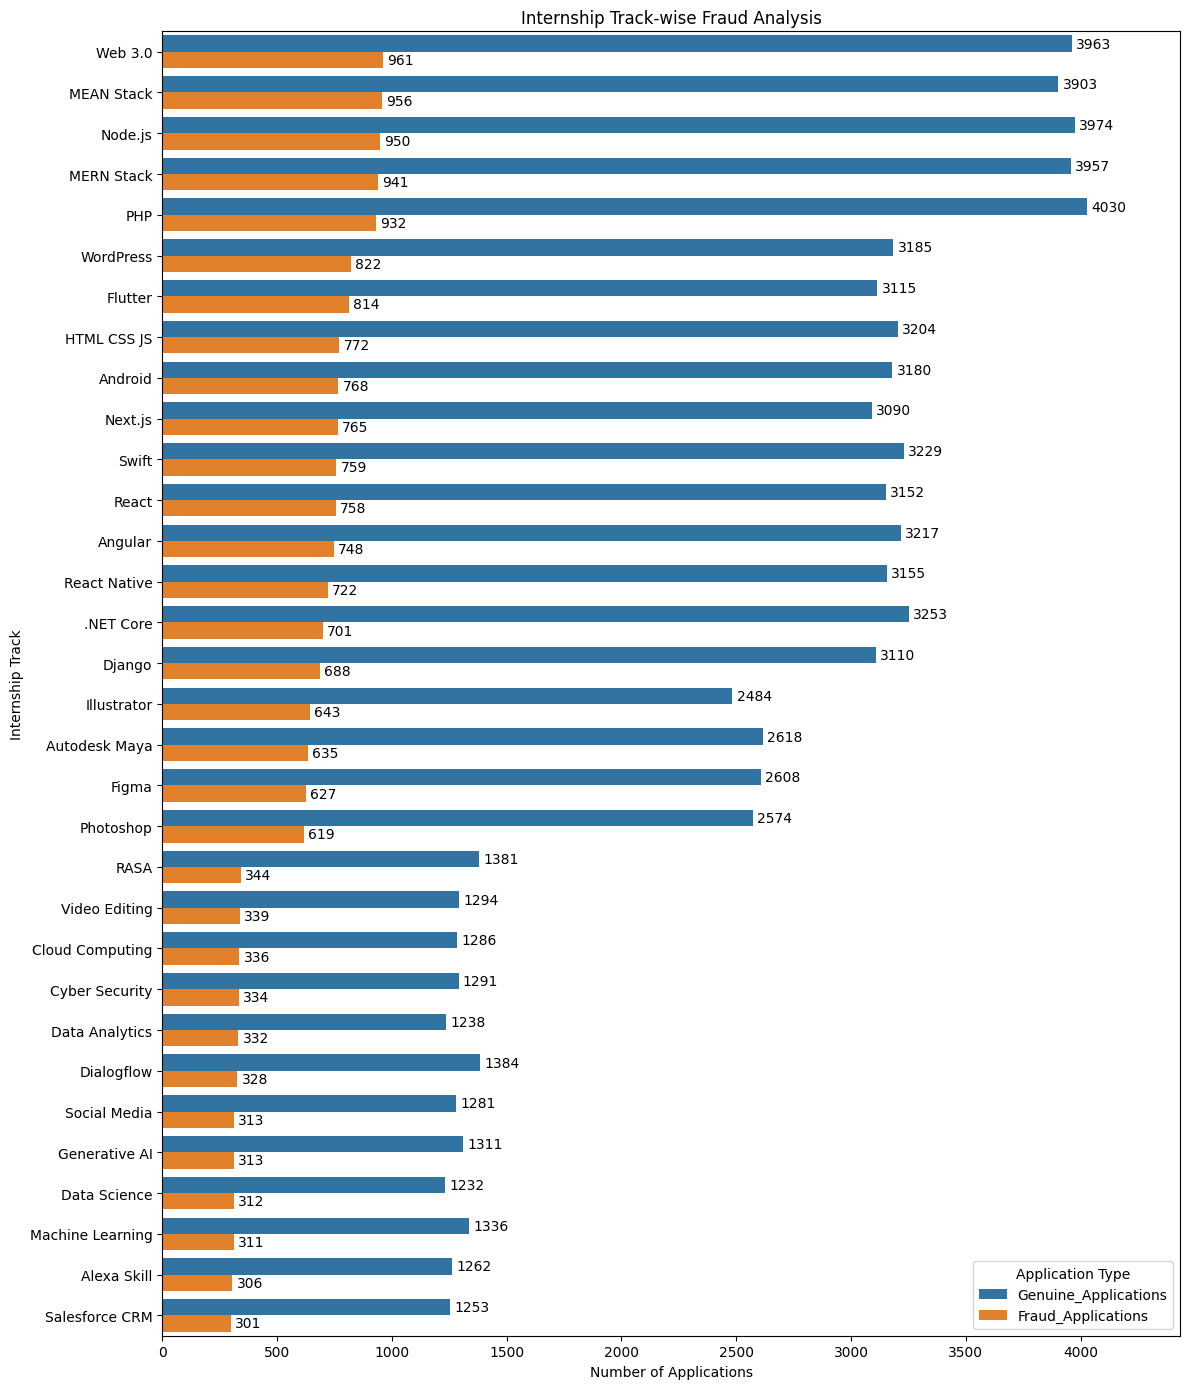

In [42]:
# ==========================================
# Internship Track-wise Fraud Analysis
# ==========================================

track_plot = (
    track_summary
    .sort_values("Fraud_Applications", ascending=False)
    [["Genuine_Applications", "Fraud_Applications"]]
    .reset_index()
    .melt(
        id_vars="Internship_Track",
        var_name="Application_Type",
        value_name="Applications"
    )
)

plt.figure(figsize=(12,14))

ax = sns.barplot(
    data=track_plot,
    y="Internship_Track",
    x="Applications",
    hue="Application_Type"
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, track_plot["Applications"].max() * 1.10)

plt.title("Internship Track-wise Fraud Analysis")
plt.xlabel("Number of Applications")
plt.ylabel("Internship Track")

plt.legend(title="Application Type")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/12_internship_track_wise_fraud_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Web 3.0** records the highest number of fraudulent internship applications (**961**), followed by **MEAN Stack (956)**, **Node.js (950)**, **MERN Stack (941)**, and **PHP (932)**, indicating that these internship tracks receive the largest number of suspicious applications.
- Although **Data Analytics** has relatively few fraudulent applications (**332**), it records the **highest fraud rate (21.15%)**, followed by **Video Editing (20.76%)** and **Flutter (20.72%)**, suggesting that these tracks have a relatively higher proportion of suspicious applications.
- Genuine applications consistently outnumber fraudulent applications across all internship tracks, indicating that legitimate submissions remain the majority regardless of the selected career path.
- Overall, both the number of fraudulent applications and the fraud rate vary across internship tracks, highlighting that some career paths are relatively more susceptible to suspicious application activity than others.

### Education Level Analysis

This analysis compares the distribution of genuine and fraudulent internship applications across different education levels. It also reports the fraud rate for each education category, helping identify educational backgrounds with a relatively higher proportion of suspicious applications.

In [43]:
# ==========================================
# Education Level Fraud Summary
# ==========================================

education_summary = (
    df_clean
    .groupby("Education_Level")["Is_Fraud"]
    .agg(
        Total_Applications="count",
        Fraud_Applications="sum"
    )
)

education_summary["Genuine_Applications"] = (
    education_summary["Total_Applications"]
    - education_summary["Fraud_Applications"]
)

education_summary["Fraud_Rate (%)"] = (
    education_summary["Fraud_Applications"]
    / education_summary["Total_Applications"]
    * 100
).round(2)

education_summary = (
    education_summary[
        [
            "Total_Applications",
            "Genuine_Applications",
            "Fraud_Applications",
            "Fraud_Rate (%)"
        ]
    ]
    .sort_values("Fraud_Rate (%)", ascending=False)
)

education_summary

,Total_Applications,Genuine_Applications,Fraud_Applications,Fraud_Rate (%)
Education_Level,,,,
BS Computer Engineering,1794,1420,374,20.85
MBA,2179,1735,444,20.38
FSC (Pre-Medical),2441,1948,493,20.20
MCS,2037,1627,410,20.13
BBA,4361,3483,878,20.13
DAE (Mechanical Technology),966,772,194,20.08
ICS,13164,10537,2627,19.96
BS Cyber Security,2777,2223,554,19.95
MS Computer Science,1693,1357,336,19.85


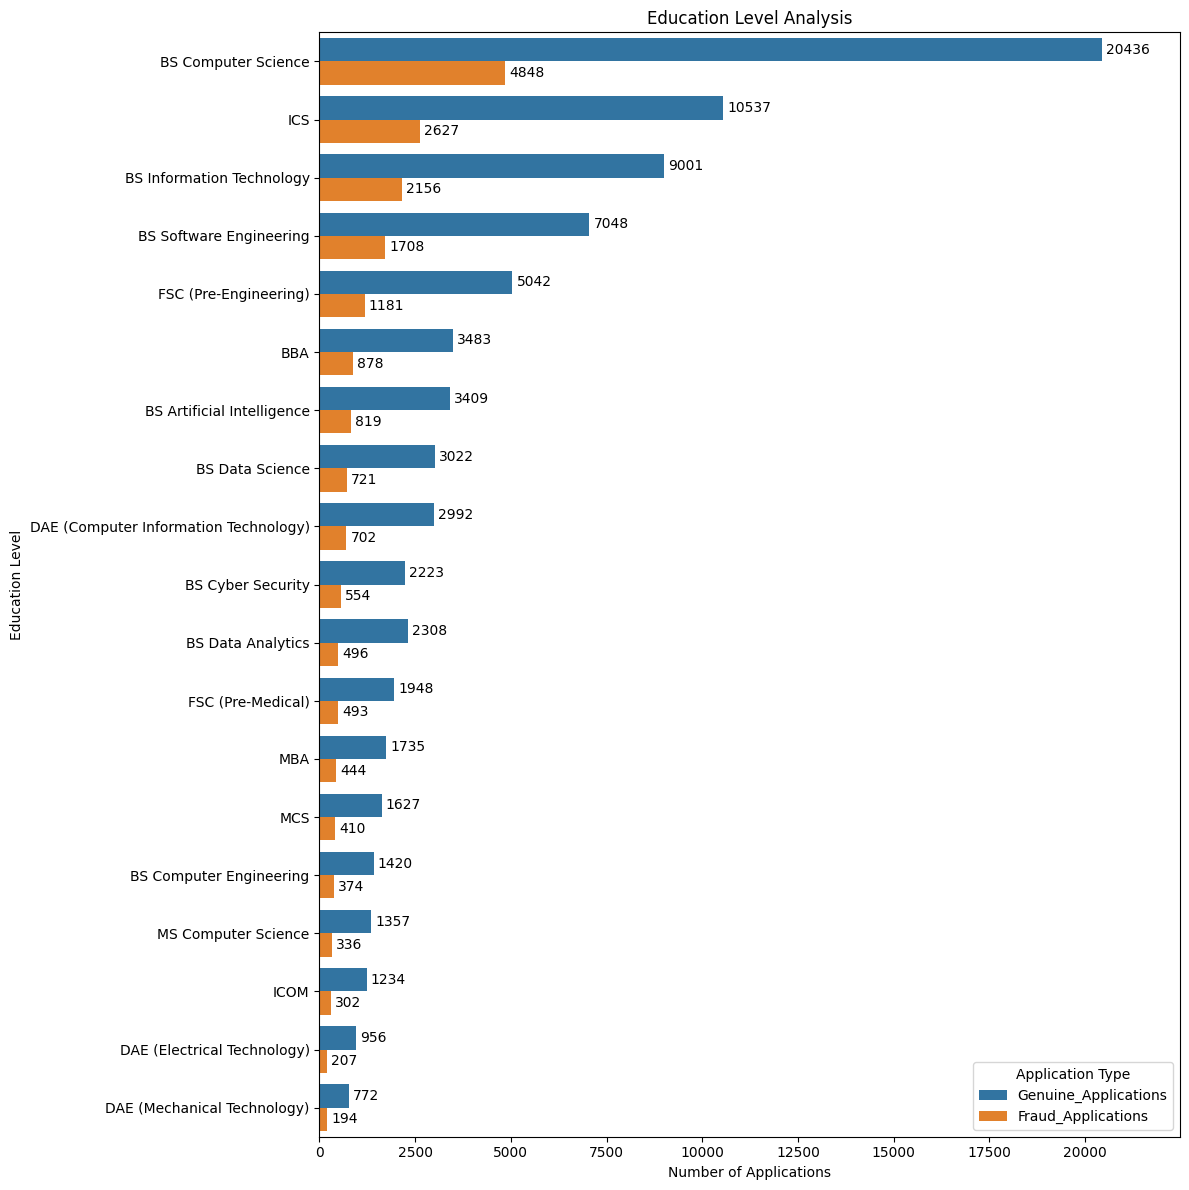

In [44]:
# ==========================================
# Education Level Analysis
# ==========================================

education_plot = (
    education_summary
    .sort_values("Fraud_Applications", ascending=False)
    [["Genuine_Applications", "Fraud_Applications"]]
    .reset_index()
    .melt(
        id_vars="Education_Level",
        var_name="Application_Type",
        value_name="Applications"
    )
)

plt.figure(figsize=(12,12))

ax = sns.barplot(
    data=education_plot,
    y="Education_Level",
    x="Applications",
    hue="Application_Type"
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, education_plot["Applications"].max() * 1.10)

plt.title("Education Level Analysis")
plt.xlabel("Number of Applications")
plt.ylabel("Education Level")

plt.legend(title="Application Type")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/13_education_level_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **BS Computer Science** receives the highest number of applications, with **20,436 genuine** and **4,848 fraudulent** applications, followed by **ICS** (**10,537 genuine**, **2,627 fraudulent**) and **BS Information Technology** (**9,001 genuine**, **2,156 fraudulent**).
- Although **BS Computer Science** records the highest number of fraudulent applications, the highest fraud rate is observed in **BS Computer Engineering (20.85%)**, followed by **MBA (20.38%)** and **FSC (Pre-Medical) (20.20%)**, indicating that these education levels have a relatively higher proportion of suspicious applications.
- **BS Data Analytics** has the lowest fraud rate (**17.69%**), while **DAE (Electrical Technology)** also shows a comparatively lower fraud rate (**17.80%**) among the education categories.
- Genuine applications consistently outnumber fraudulent applications across all education levels, indicating that legitimate submissions remain the majority regardless of applicants' educational backgrounds.

### Experience Level Analysis

This analysis compares the distribution of genuine and fraudulent internship applications across different experience levels. It also reports the fraud rate for each experience category, helping identify applicant groups with a relatively higher proportion of suspicious applications.

In [45]:
# ==========================================
# Experience Level Fraud Summary
# ==========================================

experience_summary = (
    df_clean
    .groupby("Experience_Level")["Is_Fraud"]
    .agg(
        Total_Applications="count",
        Fraud_Applications="sum"
    )
)

experience_summary["Genuine_Applications"] = (
    experience_summary["Total_Applications"]
    - experience_summary["Fraud_Applications"]
)

experience_summary["Fraud_Rate (%)"] = (
    experience_summary["Fraud_Applications"]
    / experience_summary["Total_Applications"]
    * 100
).round(2)

experience_summary = (
    experience_summary[
        [
            "Total_Applications",
            "Genuine_Applications",
            "Fraud_Applications",
            "Fraud_Rate (%)"
        ]
    ]
    .sort_values("Fraud_Rate (%)", ascending=False)
)

experience_summary

,Total_Applications,Genuine_Applications,Fraud_Applications,Fraud_Rate (%)
Experience_Level,,,,
Intermediate,19843,15969,3874,19.52
Fresher,74468,59978,14490,19.46
Experienced,5689,4603,1086,19.09


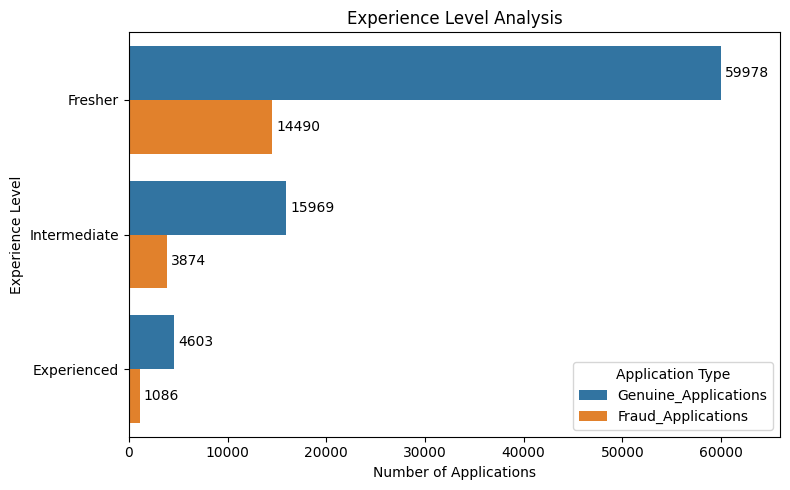

In [46]:
# ==========================================
# Experience Level Analysis
# ==========================================

experience_plot = (
    experience_summary
    .sort_values("Fraud_Applications", ascending=False)
    [["Genuine_Applications", "Fraud_Applications"]]
    .reset_index()
    .melt(
        id_vars="Experience_Level",
        var_name="Application_Type",
        value_name="Applications"
    )
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=experience_plot,
    y="Experience_Level",
    x="Applications",
    hue="Application_Type"
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, experience_plot["Applications"].max() * 1.10)

plt.title("Experience Level Analysis")
plt.xlabel("Number of Applications")
plt.ylabel("Experience Level")

plt.legend(title="Application Type")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/14_experience_level_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- **Freshers** represent the largest applicant group, with **59,978 genuine** and **14,490 fraudulent** applications, indicating that applicants with no prior experience submit the highest number of internship applications.
- **Intermediate** applicants record **15,969 genuine** and **3,874 fraudulent** applications, while **Experienced** applicants have the fewest applications, with **4,603 genuine** and **1,086 fraudulent** applications.
- The highest fraud rate is observed among **Intermediate applicants (19.52%)**, followed by **Freshers (19.46%)**, whereas **Experienced applicants (19.09%)** have the lowest fraud rate.
- Genuine applications consistently outnumber fraudulent applications across all experience levels, indicating that legitimate submissions remain the majority regardless of applicants' prior experience.

## Numerical Feature Analysis

This section analyzes the distributions of key numerical features in the internship application dataset. The analysis helps understand applicant characteristics, identify unusual values, and examine data patterns that may contribute to suspicious application behavior.

### CGPA Distribution Analysis

This analysis examines the distribution of applicants' CGPA values. It provides an overview of academic performance and helps identify unusually low or high CGPA values through both the distribution and box plot.

In [47]:
# ==========================================
# CGPA Summary Statistics
# ==========================================

df_clean["CGPA"].describe()

count    100000.000000
mean          3.350444
std           0.440437
min           0.800000
25%           3.100000
50%           3.500000
75%           3.700000
max           4.000000
Name: CGPA, dtype: float64

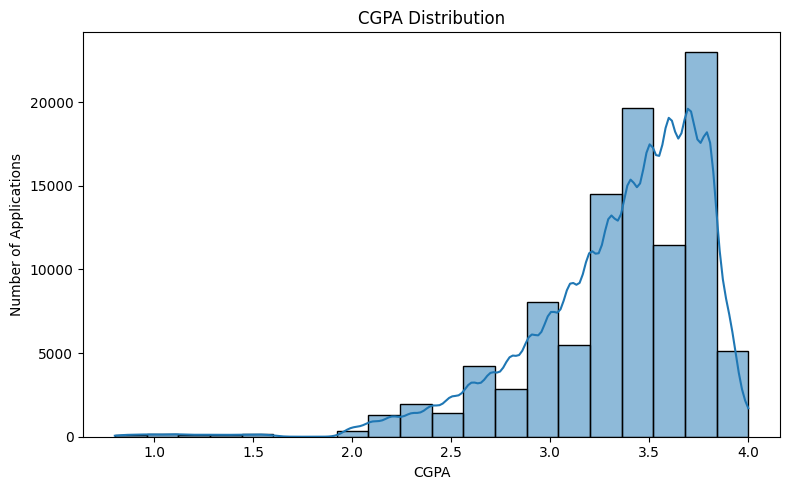

In [48]:
# ==========================================
# CGPA Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="CGPA",
    bins=20,
    kde=True
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/15_cgpa_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

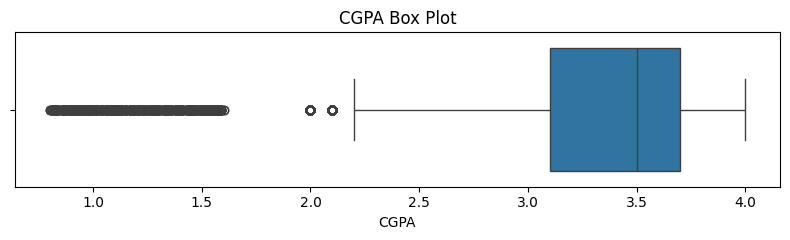

In [49]:
# ==========================================
# CGPA Box Plot
# ==========================================

plt.figure(figsize=(8,2.5))

sns.boxplot(
    data=df_clean,
    x="CGPA"
)

plt.title("CGPA Box Plot")
plt.xlabel("CGPA")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/16_cgpa_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **CGPA** values range from **0.80 to 4.00**, with an average CGPA of approximately **3.35**, indicating that most applicants have relatively strong academic performance.
- The histogram shows that the majority of applicants have CGPA values between **3.0 and 4.0**, with comparatively fewer applicants having lower CGPA values, resulting in a **left-skewed (negatively skewed)** distribution.
- The box plot reveals several **low-end outliers**, representing applicants with unusually low CGPA values, while no significant high-end outliers are observed.
- The middle 50% of applicants have CGPA values approximately between **3.10 and 3.70**, with a median of about **3.50**, indicating that most applicants fall within a relatively high academic performance range.
- Overall, the CGPA feature shows a concentration of higher academic scores with a small number of low-CGPA outliers, making it a useful numerical feature for further exploratory analysis and fraud detection.

### Profile Completion Analysis

This analysis examines the distribution of applicants' profile completion percentages. It helps evaluate how completely applicants filled their internship profiles and identifies unusually low or high completion values through both the distribution and box plot.

In [50]:
# ==========================================
# Profile Completion Summary Statistics
# ==========================================

df_clean["Profile_Completion"].describe()

count    100000.000000
mean         84.109660
std          10.992801
min          15.000000
25%          81.000000
50%          86.000000
75%          90.000000
max         100.000000
Name: Profile_Completion, dtype: float64

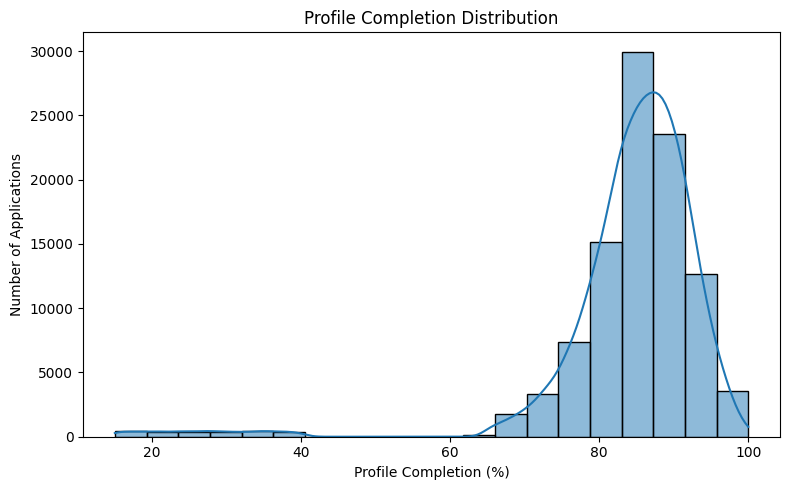

In [51]:
# ==========================================
# Profile Completion Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Profile_Completion",
    bins=20,
    kde=True
)

plt.title("Profile Completion Distribution")
plt.xlabel("Profile Completion (%)")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/17_profile_completion_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

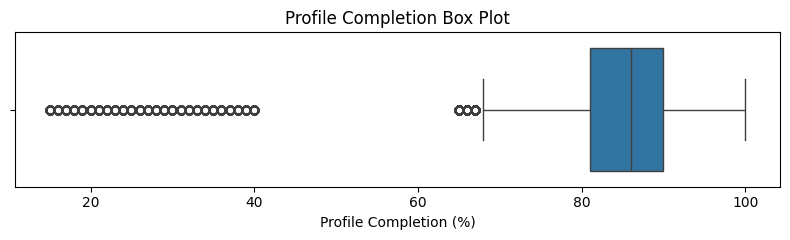

In [52]:
# ==========================================
# Profile Completion Box Plot
# ==========================================

plt.figure(figsize=(8,2.5))

sns.boxplot(
    data=df_clean,
    x="Profile_Completion"
)

plt.title("Profile Completion Box Plot")
plt.xlabel("Profile Completion (%)")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/18_profile_completion_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **Profile Completion** values range from **15% to 100%**, with an average profile completion of approximately **84.11%**, indicating that most applicants have well-completed internship profiles.
- The histogram shows that the majority of applications have **profile completion values between 80% and 100%**, while relatively few applications have substantially lower completion percentages.
- The box plot reveals several **lower-end outliers**, representing applicants with unusually low profile completion percentages. These records are consistent with the intentionally generated **Low Profile Completion** fraud indicator in the dataset.
- The middle 50% of applicants have profile completion values approximately between **81% and 90%**, with a median of **86%**, indicating that at least half of the applicants completed a large portion of their profiles.
- Overall, the profile completion feature is concentrated at higher percentages with a small number of low-completion outliers, making it a useful numerical feature for exploratory analysis and fraud detection.

### Submission Gap Analysis

This analysis examines the distribution of the time gap between consecutive internship application submissions. It helps identify normal submission behavior and unusually short submission intervals that may indicate suspicious or automated application activity.

In [53]:
# ==========================================
# Submission Gap Summary Statistics
# ==========================================

df_clean["Submission_Gap_Seconds"].describe()

count    100000.000000
mean      40706.431720
std       26204.580649
min           2.000000
25%       17666.000000
50%       40516.000000
75%       63551.250000
max       86400.000000
Name: Submission_Gap_Seconds, dtype: float64

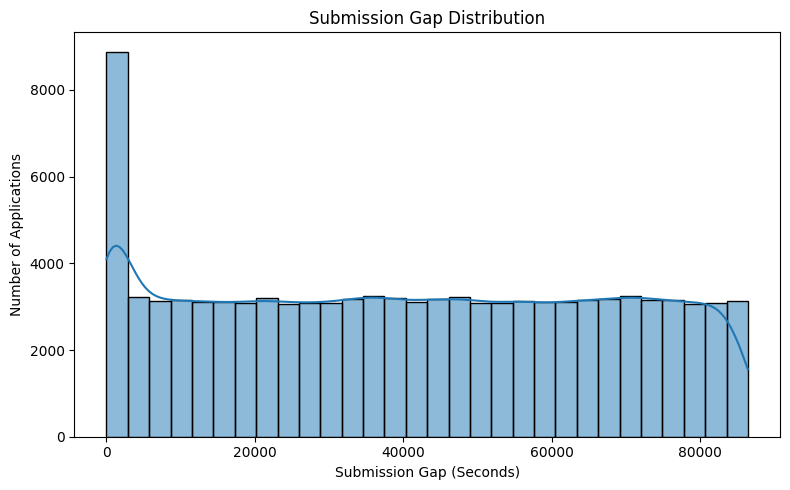

In [54]:
# ==========================================
# Submission Gap Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Submission_Gap_Seconds",
    bins=30,
    kde=True
)

plt.title("Submission Gap Distribution")
plt.xlabel("Submission Gap (Seconds)")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/19_submission_gap_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

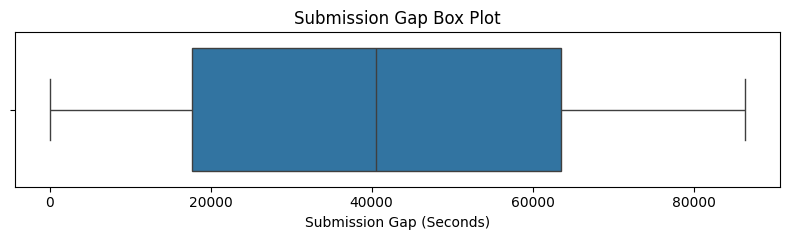

In [55]:
# ==========================================
# Submission Gap Box Plot
# ==========================================

plt.figure(figsize=(8,2.5))

sns.boxplot(
    data=df_clean,
    x="Submission_Gap_Seconds"
)

plt.title("Submission Gap Box Plot")
plt.xlabel("Submission Gap (Seconds)")

plt.tight_layout()

# Save Figure
# plt.savefig(
#     "../outputs/figures/20_submission_gap_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

- The **Submission Gap** values range from **2 seconds to 86,400 seconds (24 hours)**, with an average submission gap of approximately **40,706 seconds**, indicating substantial variation in application submission times.
- The histogram shows a noticeable concentration of applications with **very short submission gaps**, corresponding to the intentionally generated **Rapid Submission** fraud indicator, while the remaining applications are distributed across a broad range of submission intervals.
- The box plot indicates that most submission gaps fall within the expected range, with the middle 50% of applications having submission gaps approximately between **17,666** and **63,551 seconds**, and a median of **40,516 seconds**.
- No significant outliers are observed in the box plot, suggesting that the submission gap values remain within the expected range of the generated dataset.
- Overall, the **Submission Gap Seconds** feature effectively distinguishes normal application behavior from unusually rapid submissions, making it an informative numerical feature for exploratory analysis and subsequent machine learning models.

## Machine Learning for Fraud Detection

This section applies unsupervised machine learning techniques to identify suspicious internship applications and discover hidden fraud patterns within the dataset. The dataset is prepared through feature engineering, feature selection, categorical encoding, and feature scaling before applying anomaly detection and clustering algorithms.

### Preparing the Machine Learning Dataset

A separate copy of the cleaned dataset is created before performing machine learning tasks. This preserves the original cleaned dataset while allowing preprocessing and feature engineering without affecting the exploratory data analysis dataset.

In [56]:
# ==========================================
# Create Machine Learning Dataset
# ==========================================

ml_df_original = df_clean.copy()

In [57]:
# ==========================================
# Machine Learning Dataset Information
# ==========================================

ml_df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Application_ID          100000 non-null  str    
 1   Applicant_Name          100000 non-null  str    
 2   Email                   100000 non-null  str    
 3   Age                     100000 non-null  int64  
 4   Gender                  100000 non-null  str    
 5   City                    100000 non-null  str    
 6   Education_Level         100000 non-null  str    
 7   Institute               100000 non-null  str    
 8   Department              100000 non-null  str    
 9   Internship_Track        100000 non-null  str    
 10  CGPA                    100000 non-null  float64
 11  Experience_Level        100000 non-null  str    
 12  Application_Date        100000 non-null  str    
 13  Application_Time        100000 non-null  str    
 14  Submission_Gap_Seconds  100000 n

**Observation:**

- A separate machine learning dataset (**ml_df_original**) was successfully created from the cleaned dataset (**df_clean**) to preserve the original data before preprocessing.
- The dataset contains **100,000 internship application records** with **25 original features**, and all columns contain **100,000 non-null values**, indicating that no missing values are present.
- The dataset includes numerical, categorical, and identifier features, providing the required information for feature engineering and subsequent preprocessing.
- Keeping **ml_df_original** unchanged ensures that feature engineering, feature selection, encoding, scaling, and machine learning model development can be performed on derived datasets without modifying the original machine learning copy.

### Feature Engineering

Feature engineering creates meaningful input variables directly from the original dataset before training the machine learning models. These engineered features represent duplicate records, submission behavior, profile completeness, resume availability, and academic consistency. The duplicate indicators preserve the original application while marking only subsequent repeated records as suspicious, following the dataset generation rules.

In [58]:
# ==========================================
# Create Feature Engineering Dataset
# ==========================================

ml_df = ml_df_original.copy()

# ==========================================
# Feature Engineering
# ==========================================

# Duplicate Email
ml_df["Duplicate_Email"] = (
    ml_df["Email"]
    .duplicated()
    .astype(int)
)

# Duplicate IP Address
ml_df["Duplicate_IP"] = (
    ml_df["IP_Address"]
    .duplicated()
    .astype(int)
)

# Duplicate Device
ml_df["Duplicate_Device"] = (
    ml_df["Device_ID"]
    .duplicated()
    .astype(int)
)

# Resume Missing
ml_df["Resume_Missing"] = (
    (ml_df["Resume_Uploaded"] == "No")
    .astype(int)
)

# Low Profile Completion
ml_df["Low_Profile_Completion"] = (
    (ml_df["Profile_Completion"] <= 60)
    .astype(int)
)

# Rapid Submission
ml_df["Rapid_Submission"] = (
    (ml_df["Submission_Gap_Seconds"] <= 25)
    .astype(int)
)

# Inconsistent Academic Data
ml_df["Inconsistent_Data"] = (
    (ml_df["CGPA"] < 2.0)
    .astype(int)
)

In [59]:
# ==========================================
# Engineered Feature Summary
# ==========================================

engineered_features = [
    "Duplicate_Email",
    "Duplicate_IP",
    "Duplicate_Device",
    "Resume_Missing",
    "Low_Profile_Completion",
    "Rapid_Submission",
    "Inconsistent_Data"
]

engineered_summary = (
    ml_df[engineered_features]
    .sum()
    .to_frame(name="Total Records")
)

engineered_summary

,Total Records
Duplicate_Email,2867
Duplicate_IP,5914
Duplicate_Device,4974
Resume_Missing,3074
Low_Profile_Completion,2477
Rapid_Submission,5847
Inconsistent_Data,636


**Observation:**

- Seven binary features were successfully engineered from the original machine learning dataset to represent key fraud-related behaviors observed in internship applications.
- The engineered features identified **2,867 duplicate email records**, **5,914 duplicate IP records**, **4,974 duplicate device records**, **3,074 missing resume records**, **2,477 low profile completion records**, **5,847 rapid submission records**, and **636 inconsistent academic records**.
- The frequency of each engineered feature is consistent with the fraud patterns identified during the exploratory data analysis, confirming that the feature engineering process correctly captures the intended suspicious behaviors.
- These engineered binary features transform domain knowledge into machine learning-ready variables, allowing anomaly detection algorithms such as **Isolation Forest** and **K-Means Clustering** to identify suspicious applications without directly using fraud labels.

### Feature Selection

Feature selection identifies the most relevant variables required for machine learning while removing identifier and target-related columns that do not contribute to anomaly detection. This step reduces unnecessary information, improves computational efficiency, and prepares the dataset for encoding and feature scaling.

In [60]:
# ==========================================
# Feature Selection
# ==========================================

selected_features = [

    # Numerical Features
    "Age",
    "CGPA",
    "Profile_Completion",
    "Submission_Gap_Seconds",

    # Engineered Features
    "Duplicate_Email",
    "Duplicate_IP",
    "Duplicate_Device",
    "Resume_Missing",
    "Low_Profile_Completion",
    "Rapid_Submission",
    "Inconsistent_Data",

    # Categorical Features
    "Gender",
    "City",
    "Education_Level",
    "Department",
    "Internship_Track",
    "Experience_Level",
    "Browser",
    "Operating_System"

]

ml_df_selected = ml_df[selected_features].copy()

In [61]:
# ==========================================
# Selected Machine Learning Dataset
# ==========================================

ml_df_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Age                     100000 non-null  int64  
 1   CGPA                    100000 non-null  float64
 2   Profile_Completion      100000 non-null  int64  
 3   Submission_Gap_Seconds  100000 non-null  int64  
 4   Duplicate_Email         100000 non-null  int64  
 5   Duplicate_IP            100000 non-null  int64  
 6   Duplicate_Device        100000 non-null  int64  
 7   Resume_Missing          100000 non-null  int64  
 8   Low_Profile_Completion  100000 non-null  int64  
 9   Rapid_Submission        100000 non-null  int64  
 10  Inconsistent_Data       100000 non-null  int64  
 11  Gender                  100000 non-null  str    
 12  City                    100000 non-null  str    
 13  Education_Level         100000 non-null  str    
 14  Department              100000 n

In [62]:
ml_df_selected.head()

,Age,CGPA,Profile_Completion,Submission_Gap_Seconds,Duplicate_Email,Duplicate_IP,Duplicate_Device,Resume_Missing,Low_Profile_Completion,Rapid_Submission,Inconsistent_Data,Gender,City,Education_Level,Department,Internship_Track,Experience_Level,Browser,Operating_System
0,18,3.9,90,45127,0,0,0,0,0,0,0,Male,Bahawalpur,BS Software Engineering,Frontend Development,React,Fresher,Google Chrome,Android
1,27,2.5,92,13283,0,0,0,0,0,0,0,Male,Multan,BS Cyber Security,Backend Development,PHP,Fresher,Google Chrome,Windows
2,26,3.0,83,7376,0,0,0,0,0,0,0,Male,Quetta,FSC (Pre-Medical),Graphic Design,Illustrator,Fresher,Google Chrome,Windows
3,23,3.2,81,56200,0,0,0,0,0,0,0,Male,Peshawar,BS Computer Science,Graphic Design,Illustrator,Fresher,Mozilla Firefox,Windows
4,20,3.3,93,1549,0,0,0,0,0,0,0,Female,Karachi,BS Information Technology,App Development,Flutter,Fresher,Microsoft Edge,Windows


**Observation:**

- A total of **19 features** were selected for machine learning after feature engineering and feature selection.
- The selected dataset contains **11 numerical/binary features** and **8 categorical features**, providing a balanced representation of applicant characteristics and fraud-related behavioral patterns.
- All **100,000 application records** contain complete values for the selected features, indicating that no missing data is present before preprocessing.
- Identifier fields, redundant attributes, and fraud-related target variables were excluded to prevent data leakage and improve model reliability.
- The selected feature set is now ready for categorical encoding, feature scaling, and unsupervised machine learning algorithms such as **Isolation Forest** and **K-Means Clustering**.

### Feature Encoding

Categorical variables must be converted into numerical representations before applying machine learning algorithms. One-hot encoding is used to transform the selected categorical features into binary variables while preserving the information contained in each category.

In [63]:
# ==========================================
# One-Hot Encoding
# ==========================================

categorical_features = [
    "Gender",
    "City",
    "Education_Level",
    "Department",
    "Internship_Track",
    "Experience_Level",
    "Browser",
    "Operating_System"
]

ml_df_encoded = pd.get_dummies(
    ml_df_selected,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [64]:
# ==========================================
# Encoded Machine Learning Dataset
# ==========================================

ml_df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 115 entries, Age to Operating_System_macOS
dtypes: float64(1), int64(114)
memory usage: 87.7 MB


In [65]:
# ==========================================
# Preview Encoded Dataset
# ==========================================

ml_df_encoded.head()

,Age,CGPA,Profile_Completion,Submission_Gap_Seconds,Duplicate_Email,Duplicate_IP,Duplicate_Device,Resume_Missing,Low_Profile_Completion,Rapid_Submission,...,Experience_Level_Fresher,Experience_Level_Intermediate,Browser_Microsoft Edge,Browser_Mozilla Firefox,Browser_Opera,Browser_Safari,Operating_System_Linux,Operating_System_Windows,Operating_System_iOS,Operating_System_macOS
0,18,3.9,90,45127,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,27,2.5,92,13283,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,26,3.0,83,7376,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
3,23,3.2,81,56200,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
4,20,3.3,93,1549,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0


**Observation:**

- Eight categorical features (**Gender, City, Education_Level, Department, Internship_Track, Experience_Level, Browser, and Operating_System**) were successfully transformed into numerical variables using one-hot encoding.
- The total number of features increased from **19 to 115** after encoding, as each categorical level was converted into a separate binary feature.
- The encoded dataset now contains only numerical features, making it fully compatible with machine learning algorithms that require numerical input.
- One-hot encoding preserves the information contained in categorical variables without introducing ordinal relationships, ensuring that the encoded features are suitable for anomaly detection using **Isolation Forest** and **K-Means Clustering**.

### Feature Scaling

Only continuous numerical features are standardized using the StandardScaler. Binary engineered features and one-hot encoded categorical variables are already on a common scale (0 and 1), so they are retained without transformation. This approach preserves the interpretability of binary features while ensuring that continuous variables contribute equally during machine learning.

In [66]:
# ==========================================
# Continuous Numerical Features
# ==========================================

continuous_features = [
    "Age",
    "CGPA",
    "Profile_Completion",
    "Submission_Gap_Seconds"
]

In [67]:
# ==========================================
# Create Scaled Dataset
# ==========================================

ml_df_scaled = ml_df_encoded.copy()

In [68]:
# ==========================================
# Standard Scaling
# ==========================================

scaler = StandardScaler()

ml_df_scaled[continuous_features] = scaler.fit_transform(
    ml_df_scaled[continuous_features]
)

In [69]:
# ==========================================
# Scaled Dataset Information
# ==========================================

ml_df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 115 entries, Age to Operating_System_macOS
dtypes: float64(4), int64(111)
memory usage: 87.7 MB


In [70]:
# ==========================================
# Preview Scaled Dataset
# ==========================================

ml_df_scaled.head()

,Age,CGPA,Profile_Completion,Submission_Gap_Seconds,Duplicate_Email,Duplicate_IP,Duplicate_Device,Resume_Missing,Low_Profile_Completion,Rapid_Submission,...,Experience_Level_Fresher,Experience_Level_Intermediate,Browser_Microsoft Edge,Browser_Mozilla Firefox,Browser_Opera,Browser_Safari,Operating_System_Linux,Operating_System_Windows,Operating_System_iOS,Operating_System_macOS
0,-2.020259,1.247756,0.535839,0.168695,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0.867416,-1.930919,0.717777,-1.046518,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0.546563,-0.795678,-0.100945,-1.271938,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
3,-0.415995,-0.341581,-0.282883,0.591257,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
4,-1.378554,-0.114533,0.808746,-1.494305,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0


**Observation:**

- The four continuous numerical features (**Age, CGPA, Profile_Completion, and Submission_Gap_Seconds**) were successfully standardized using **StandardScaler**, while binary engineered features and one-hot encoded variables remained unchanged.
- The scaled dataset retains **100,000 internship application records** and **115 machine learning features**, ensuring that no information was lost during preprocessing.
- Keeping binary features in their original **0/1** format preserves their interpretability, while scaling continuous variables prevents features with larger numerical ranges from dominating the machine learning models.
- The dataset is now fully prepared for anomaly detection using **Isolation Forest** and clustering using **K-Means**, with all features in an appropriate format for model training.

### Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm that identifies unusual observations by isolating data points through random partitioning. Applications that are isolated more quickly are considered anomalous. In this project, Isolation Forest is used to detect suspicious internship applications based on applicant characteristics and engineered fraud-related features without using fraud labels during model training.

In [71]:
# ==========================================
# Fraud Ratio
# ==========================================

fraud_ratio = ml_df_original["Is_Fraud"].mean()

print(f"Fraud Ratio: {fraud_ratio:.4f}")

Fraud Ratio: 0.1945


In [72]:
# ==========================================
# Train Isolation Forest Model
# ==========================================

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=fraud_ratio,
    random_state=42
)

isolation_forest.fit(ml_df_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",np.float64(0.1945)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [73]:
# ==========================================
# Create Machine Learning Results Dataset
# ==========================================

if_results = ml_df_scaled.copy()

In [74]:
# ==========================================
# Predict Anomalies
# ==========================================

if_results["IF_Prediction"] = (
    isolation_forest.predict(ml_df_scaled)
)

In [75]:
# ==========================================
# Convert Predictions
# ==========================================

if_results["IF_Anomaly"] = (
    (if_results["IF_Prediction"] == -1)
    .astype(int)
)

In [76]:
# ==========================================
# Add Actual Fraud Labels
# ==========================================

if_results["Actual_Fraud"] = (
    ml_df_original["Is_Fraud"].values
)

#### Prediction Summary

The trained Isolation Forest model classifies each internship application into one of the following categories:

- **Normal (0)** – Application follows normal behavioral patterns.
- **Anomalous (1)** – Application exhibits unusual characteristics and is flagged as suspicious.

In [77]:
# ==========================================
# Isolation Forest Prediction Summary
# ==========================================

if_summary = (
    if_results["IF_Anomaly"]
    .value_counts()
    .rename(index={
        0: "Normal Applications",
        1: "Anomalous Applications"
    })
    .to_frame(name="Total Applications")
)

if_summary

,Total Applications
IF_Anomaly,
Normal Applications,80550
Anomalous Applications,19450


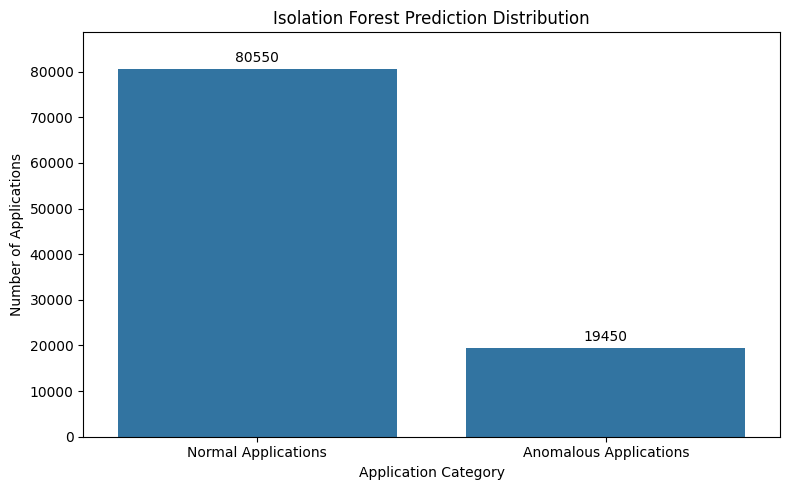

In [78]:
# ==========================================
# Isolation Forest Prediction Distribution
# ==========================================

from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=if_results,
    x="IF_Anomaly",
    order=[0, 1]
)

# Title and Labels
plt.title("Isolation Forest Prediction Distribution")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")

# Rename X-axis Categories
ax.set_xticks(range(2))
ax.set_xticklabels([
    "Normal Applications",
    "Anomalous Applications"
])

# Y-axis Limit
max_count = if_results["IF_Anomaly"].value_counts().max()
plt.ylim(0, max_count * 1.10)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Save Figure
# plt.savefig(
#     "../outputs/figures/21_isolation_forest_prediction_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The Isolation Forest model classified **80,550 applications (80.55%)** as normal and **19,450 applications (19.45%)** as anomalous.
- The detected anomaly proportion closely matches the expected contamination ratio (**19.45%**), indicating that the model successfully isolated the intended percentage of suspicious internship applications.
- Since Isolation Forest is an unsupervised learning algorithm, anomaly predictions were generated without using the actual **Is_Fraud** labels during model training.
- The predicted anomaly labels will be evaluated against the actual **Is_Fraud** labels in the following section to assess the fraud detection performance of the model.

#### Isolation Forest Evaluation

The performance of the Isolation Forest model is evaluated by comparing the predicted anomaly labels with the actual fraud labels available in the dataset. Although Isolation Forest is an unsupervised learning algorithm, these evaluation metrics provide valuable insights into its effectiveness in identifying fraudulent internship applications.

In [79]:
# ==========================================
# Calculate Evaluation Metrics
# ==========================================

if_accuracy = accuracy_score(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

if_precision = precision_score(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

if_recall = recall_score(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

if_f1 = f1_score(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

In [80]:
# ==========================================
# Isolation Forest Evaluation Summary
# ==========================================

if_evaluation_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Score": [
        if_accuracy,
        if_precision,
        if_recall,
        if_f1
    ]

})

if_evaluation_summary["Score"] = (
    if_evaluation_summary["Score"] * 100
).round(2).astype(str) + "%"

if_evaluation_summary

,Metric,Score
0,Accuracy,79.84%
1,Precision,48.17%
2,Recall,48.17%
3,F1-Score,48.17%


**Observation:**

- The Isolation Forest model achieved an **accuracy of 79.84%**, correctly classifying nearly four out of every five internship applications.
- The model achieved a **precision of 48.17%**, indicating that approximately half of the applications predicted as fraudulent were actually fraud cases.
- The model achieved a **recall of 48.17%**, successfully identifying nearly half of the fraudulent applications present in the dataset.
- The **F1-score of 48.17%** indicates a balanced trade-off between precision and recall, demonstrating that the model provides a reasonable baseline for unsupervised fraud detection while leaving room for further improvement in identifying fraudulent applications.

#### Classification Report

The classification report summarizes the predictive performance of the Isolation Forest model using precision, recall, F1-score, and support for both normal and fraudulent internship applications.

In [81]:
# ==========================================
# Isolation Forest Classification Report
# ==========================================

if_report = classification_report(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

print(if_report)

              precision    recall  f1-score   support

           0       0.87      0.87      0.87     80550
           1       0.48      0.48      0.48     19450

    accuracy                           0.80    100000
   macro avg       0.68      0.68      0.68    100000
weighted avg       0.80      0.80      0.80    100000



**Observation:**

- The classification report shows that the Isolation Forest model achieved **87% precision, recall, and F1-score** for **normal applications**, indicating strong performance in correctly identifying legitimate internship applications.
- For **fraudulent applications**, the model achieved **48% precision, 48% recall, and 48% F1-score**, demonstrating moderate performance in detecting suspicious applications.
- The model achieved an overall **accuracy of approximately 80%**, indicating that it correctly classified the majority of internship applications.
- The **weighted average F1-score of 0.80** suggests good overall classification performance, while the lower fraud detection metrics indicate that identifying fraudulent applications remains more challenging than identifying normal applications.

#### Confusion Matrix

The confusion matrix provides a detailed comparison between the actual fraud labels and the predictions generated by the Isolation Forest model. It summarizes the number of correctly and incorrectly classified internship applications, including true positives, true negatives, false positives, and false negatives, providing a comprehensive evaluation of the model's classification performance.

In [82]:
# ==========================================
# Isolation Forest Confusion Matrix
# ==========================================

if_cm = confusion_matrix(
    if_results["Actual_Fraud"],
    if_results["IF_Anomaly"]
)

if_cm = pd.DataFrame(
    if_cm,
    index=[
        "Actual Normal",
        "Actual Fraud"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Fraud"
    ]
)

if_cm

,Predicted Normal,Predicted Fraud
Actual Normal,70470,10080
Actual Fraud,10080,9370


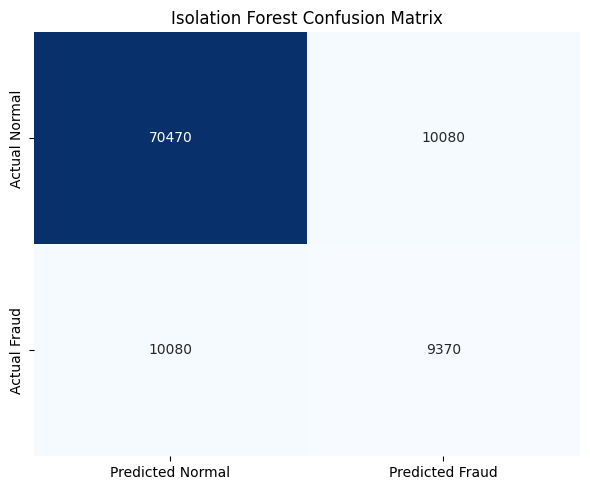

In [83]:
# ==========================================
# Isolation Forest Confusion Matrix Heatmap
# ==========================================

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    if_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Isolation Forest Confusion Matrix")

# Save Figure
# plt.savefig(
#     "../outputs/figures/22_isolation_forest_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The confusion matrix shows that the Isolation Forest model correctly classified **70,470 normal applications** and **9,370 fraudulent applications**.
- A total of **10,080 normal applications** were incorrectly classified as fraudulent (**False Positives**), while **10,080 fraudulent applications** were incorrectly classified as normal (**False Negatives**).
- These results indicate that the model performs well in identifying normal applications, while fraud detection remains moderately challenging due to the overlap between normal and suspicious application patterns.
- Overall, the confusion matrix supports the evaluation metrics, confirming that the Isolation Forest model provides a reasonable baseline for unsupervised fraud detection.

### K-Means Clustering

K-Means is an unsupervised machine learning algorithm that partitions similar observations into distinct clusters based on feature similarity. In this project, K-Means clustering is applied to group internship applications with similar characteristics and investigate whether fraudulent applications naturally form separate clusters without using the actual fraud labels during model training.

#### Elbow Method

The Elbow Method is used to determine the optimal number of clusters for the K-Means algorithm. It evaluates different cluster sizes by calculating the Within-Cluster Sum of Squares (WCSS), also known as inertia. The point where the decrease in WCSS starts to slow down indicates a suitable number of clusters. Since the Elbow Method may not always produce a clearly defined elbow point, the result will later be validated using Silhouette Analysis before selecting the final number of clusters.

In [84]:
# ==========================================
# Calculate WCSS
# ==========================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(ml_df_scaled)

    wcss.append(
        kmeans.inertia_
    )

wcss

[887447.1366699986,
 811712.902862,
 743441.7580991361,
 694796.6425280363,
 655015.837759545,
 639208.099164257,
 627969.1745677876,
 618334.1826760182,
 610200.8107335217,
 602360.8580066161]

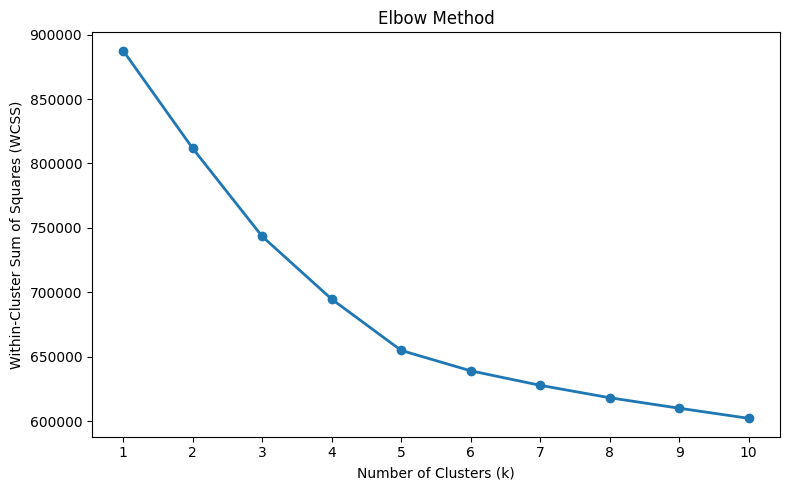

In [85]:
# ==========================================
# Elbow Method
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")

plt.xticks(range(1, 11))

# Save Figure

# plt.savefig(
#     "../outputs/figures/23_elbow_method.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The WCSS decreases steadily as the number of clusters increases, indicating improved clustering with additional clusters.
- The rate of decrease becomes more gradual as the number of clusters increases, suggesting diminishing improvements from adding more clusters.
- However, the elbow point is not sharply defined in this dataset, making it difficult to determine the optimal number of clusters based solely on the Elbow Method.
- Therefore, **Silhouette Analysis** will be performed in the next step to validate the optimal number of clusters before training the final K-Means model.

#### Silhouette Analysis

Silhouette Analysis is used to evaluate the quality of clustering by measuring how similar each observation is to its own cluster compared to other clusters. The Silhouette Score ranges from **-1 to 1**, where a higher value indicates better-defined and more compact clusters.

Unlike the Elbow Method, Silhouette Analysis provides a quantitative measure of clustering quality. Therefore, it is used together with the Elbow Method to determine the optimal number of clusters before training the final K-Means model.

In [ ]:
# ==========================================
# Calculate Silhouette Scores
# ==========================================

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        ml_df_scaled
    )

    score = silhouette_score(
        ml_df_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

silhouette_scores

In [ ]:
# ==========================================
# Silhouette Score Analysis
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))

# Save Figure

# plt.savefig(
#     "../outputs/figures/24_silhouette_score_analysis.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The Silhouette Score was calculated for cluster sizes ranging from **2 to 10** to evaluate clustering quality.
- The **highest Silhouette Score (0.0956)** was achieved when **k = 3**, indicating that three clusters provide the best separation and cohesion among the internship applications.
- After **k = 3**, the Silhouette Score gradually decreases, suggesting that increasing the number of clusters reduces clustering quality.
- Considering both the **Elbow Method** and **Silhouette Analysis**, the final number of clusters was selected as **3** for training the K-Means clustering model.

#### K-Means Model Training

After determining the optimal number of clusters using the Elbow Method and validating it through Silhouette Analysis, the K-Means clustering model is trained using **three clusters (k = 3)**. The algorithm partitions internship applications into groups based on feature similarity without using the actual fraud labels during training.

In [ ]:
# ==========================================
# Train K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(ml_df_scaled)

In [ ]:
# ==========================================
# Create Results Dataset
# ==========================================

kmeans_results = ml_df_scaled.copy()

kmeans_results["Cluster"] = (
    kmeans.labels_
)

#### Cluster Summary

The cluster summary presents the number of internship applications assigned to each cluster by the trained K-Means model. Since K-Means is an unsupervised learning algorithm, these clusters are formed solely based on feature similarity without considering the actual fraud labels.

In [ ]:
# ==========================================
# K-Means Cluster Summary
# ==========================================

kmeans_summary = (
    kmeans_results["Cluster"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Cluster 0",
        1: "Cluster 1",
        2: "Cluster 2"
    })
    .to_frame(name="Total Applications")
)

kmeans_summary

In [ ]:
# ==========================================
# K-Means Cluster Distribution
# ==========================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=kmeans_results,
    x="Cluster",
    order=[0, 1, 2]
)

plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Applications")

ax.set_xticks(range(3))
ax.set_xticklabels([
    "Cluster 0",
    "Cluster 1",
    "Cluster 2"
])

max_count = (
    kmeans_results["Cluster"]
    .value_counts()
    .max()
)

plt.ylim(0, max_count * 1.10)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Save Figure

# plt.savefig(
#     "../outputs/figures/25_kmeans_cluster_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The K-Means algorithm partitioned the **100,000 internship applications** into **three distinct clusters**.
- **Cluster 0** contains **2,477 applications (2.48%)**, making it the smallest cluster in the dataset.
- **Cluster 1** and **Cluster 2** contain **48,675 (48.68%)** and **48,848 (48.85%)** applications, respectively, indicating that the majority of applications are distributed almost equally between these two clusters.
- The cluster distribution suggests that the K-Means algorithm identified one relatively small cluster and two large clusters, highlighting the presence of a distinct subgroup within the internship application dataset.

#### PCA Visualization

Principal Component Analysis (PCA) is applied to reduce the high-dimensional feature space into two principal components for visualization purposes. This dimensionality reduction technique preserves most of the data variation while enabling the K-Means clustering results to be displayed in a two-dimensional space. The visualization helps examine the separation and similarity among the identified clusters.

In [ ]:
# ==========================================
# Apply Principal Component Analysis (PCA)
# ==========================================

pca = PCA(
    n_components=2,
    random_state=42
)

pca_components = pca.fit_transform(
    ml_df_scaled
)

In [ ]:
# ==========================================
# Create PCA Dataset
# ==========================================

kmeans_pca = pd.DataFrame(
    pca_components,
    columns=[
        "Principal_Component_1",
        "Principal_Component_2"
    ]
)

kmeans_pca["Cluster"] = (
    kmeans_results["Cluster"]
)

In [ ]:
# ==========================================
# K-Means Cluster Visualization using PCA
# ==========================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmeans_pca,
    x="Principal_Component_1",
    y="Principal_Component_2",
    hue="Cluster",
    palette="Set1",
    s=15,
    alpha=0.70
)

plt.title("K-Means Cluster Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Cluster"
)

# Save Figure

# plt.savefig(
#     "../outputs/figures/26_kmeans_pca_visualization.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- PCA reduced the high-dimensional internship application dataset into **two principal components**, making the K-Means clustering results easier to visualize and interpret.
- **Cluster 0** is clearly separated from the other two clusters, indicating that it represents a distinct group of internship applications with unique feature characteristics.
- **Clusters 1 and 2** are positioned close to each other with a moderate overlapping region, suggesting that these applications share similar feature patterns while still forming two distinguishable clusters.
- The visualization demonstrates that the K-Means algorithm successfully grouped internship applications into meaningful clusters based on feature similarity without using the actual fraud labels during training.

#### Cluster vs Actual Fraud

Although K-Means is an unsupervised learning algorithm and does not use fraud labels during training, the identified clusters can be compared with the actual fraud labels available in the original dataset. This post-clustering analysis helps examine how normal and fraudulent internship applications are distributed across the discovered clusters and provides insights into the effectiveness of the clustering process.

In [ ]:
# ==========================================
# Cluster vs Actual Fraud
# ==========================================

kmeans_results["Actual_Fraud"] = (
    ml_df_original["Is_Fraud"]
)

cluster_fraud_summary = (
    pd.crosstab(
        kmeans_results["Cluster"],
        kmeans_results["Actual_Fraud"]
    )
    .rename(columns={
        0: "Normal Applications",
        1: "Fraudulent Applications"
    })
)

cluster_fraud_summary

In [ ]:
# ==========================================
# Cluster vs Actual Fraud Heatmap
# ==========================================

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cluster_fraud_summary,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    annot_kws={
        "size":11
    }
)

plt.title("Cluster vs Actual Fraud")
plt.xlabel("Application Category")
plt.ylabel("Cluster")

# Save Figure

# plt.savefig(
#     "../outputs/figures/27_cluster_vs_actual_fraud_heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation:**

- The heatmap presents the distribution of **normal** and **fraudulent internship applications** across the three clusters generated by the K-Means algorithm.
- **Cluster 0** consists of **2,477 applications**, all of which are labeled as **fraudulent** in the original dataset, while no normal applications are assigned to this cluster.
- **Cluster 1** contains **42,773 normal applications** and **5,902 fraudulent applications**, indicating that this cluster is predominantly composed of legitimate internship applications.
- **Cluster 2** contains **37,777 normal applications** and **11,071 fraudulent applications**, representing a mixed cluster with a comparatively higher proportion of fraudulent applications than Cluster 1.
- Since the actual fraud labels were introduced **only after the clustering process**, these results demonstrate that the K-Means algorithm naturally grouped applications with similar characteristics without using fraud labels during model training.

#### K-Means Clustering Findings

The K-Means clustering analysis grouped internship applications into distinct clusters based on feature similarity without using the actual fraud labels during model training. The subsequent comparison with the original fraud labels provides valuable insights into how fraudulent and normal applications are distributed across the identified clusters.

**Key Findings:**

- The Elbow Method and Silhouette Analysis indicated that **three clusters (k = 3)** were appropriate for clustering the internship application dataset.
- The K-Means algorithm successfully partitioned **100,000 internship applications** into three distinct clusters based solely on feature similarity.
- PCA visualization confirmed that **Cluster 0** is clearly separated from the other clusters, while **Clusters 1 and 2** exhibit partial overlap, indicating similar but distinguishable application patterns.
- The post-clustering analysis revealed that **Cluster 0** contains only fraudulent applications, whereas **Clusters 1 and 2** contain a mixture of normal and fraudulent applications with different fraud proportions.
- Since the actual fraud labels were introduced only after clustering, these findings demonstrate that K-Means naturally grouped applications with similar behavioral characteristics without prior knowledge of the fraud labels.
- Overall, the clustering results provide meaningful insights into the underlying structure of the internship application dataset and highlight behavioral patterns that can support exploratory fraud analysis.

### Model Comparison

This section compares the two machine learning algorithms used in this project: **Isolation Forest** and **K-Means Clustering**. The comparison highlights their learning approach, objective, output, evaluation methods, and suitability for detecting fraudulent internship applications.

In [ ]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Aspect": [
        "Learning Type",
        "Primary Objective",
        "Model Type",
        "Output",
        "Fraud Labels Used During Training",
        "Evaluation Method",
        "Strength",
        "Limitation",
        "Best Use Case"
    ],

    "Isolation Forest": [
        "Unsupervised",
        "Anomaly Detection",
        "Tree-Based",
        "Normal / Anomaly",
        "No",
        "Confusion Matrix, Accuracy, Precision, Recall, F1-Score",
        "Detects anomalous applications directly",
        "Performance depends on anomaly contamination",
        "Fraud Detection"
    ],

    "K-Means Clustering": [
        "Unsupervised",
        "Pattern Discovery",
        "Centroid-Based Clustering",
        "Cluster Labels",
        "No",
        "Cluster Analysis, PCA Visualization, Heatmap",
        "Groups applications with similar characteristics",
        "Does not directly classify fraud",
        "Behavioral Pattern Analysis"
    ]

})

comparison

**Observation:**

- Both **Isolation Forest** and **K-Means Clustering** are unsupervised machine learning algorithms and were trained without using the actual fraud labels.
- **Isolation Forest** is specifically designed for anomaly detection and directly identifies suspicious internship applications as normal or anomalous.
- **K-Means Clustering** groups internship applications based on feature similarity, making it useful for discovering hidden behavioral patterns rather than directly detecting fraud.
- While Isolation Forest provides quantitative evaluation through classification metrics, K-Means offers exploratory insights through cluster analysis and visualization techniques.
- The combined use of both algorithms provides a comprehensive understanding of fraudulent internship applications by supporting both anomaly detection and behavioral pattern analysis.

## Conclusion

This project developed a machine learning-based framework for detecting fraudulent internship applications using **Isolation Forest** and **K-Means Clustering**. After preprocessing, feature engineering, encoding, and feature scaling, both unsupervised learning algorithms were applied to analyze internship application data.

Isolation Forest successfully identified anomalous applications and was evaluated using standard classification metrics. K-Means Clustering grouped internship applications based on feature similarity, and post-clustering analysis demonstrated meaningful behavioral patterns among the discovered clusters.

The results indicate that combining anomaly detection with clustering provides valuable insights into suspicious internship applications and can support organizations in identifying potential fraudulent behavior more effectively.